In [1]:
import os

project_root = ".."

scraping_dir = os.path.join(project_root, "01_scraping")
cleaning_dir = os.path.join(project_root, "02_cleaning_and_curation")
structured_dir = os.path.join(project_root, "03_structured_data")
outputs_dir = os.path.join(project_root, "04_outputs")

print("scraping_dir:", scraping_dir)
print("cleaning_dir:", cleaning_dir)
print("structured_dir:", structured_dir)
print("outputs_dir:", outputs_dir)

scraping_dir: ..\01_scraping
cleaning_dir: ..\02_cleaning_and_curation
structured_dir: ..\03_structured_data
outputs_dir: ..\04_outputs


In [1]:
!pip install -U pandas matplotlib requests


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [3]:
base_dir = "."
raw_csv_dir = os.path.join(base_dir, "raw_csv")
raw_outputs_dir = os.path.join(base_dir, "raw_outputs")

os.makedirs(raw_csv_dir, exist_ok=True)
os.makedirs(raw_outputs_dir, exist_ok=True)

print("raw_csv_dir:", raw_csv_dir)
print("raw_outputs_dir:", raw_outputs_dir)

raw_csv_dir: .\raw_csv
raw_outputs_dir: .\raw_outputs


In [4]:
FREESOUND_API_KEY = "bMrT-"

if FREESOUND_API_KEY:
    print("Freesound API key loaded:", FREESOUND_API_KEY[:4] + "..." + FREESOUND_API_KEY[-4:])
else:
    print("No Freesound API key found")

Freesound API key loaded: bMrT...1YLl


In [5]:
test_url = "https://freesound.org/apiv2/search/text/"

params = {
    "token": FREESOUND_API_KEY,
    "query": "rustle",
    "page_size": 1
}

r = requests.get(test_url, params=params, timeout=30)

print("Status code:", r.status_code)
print(r.text[:300])

Status code: 200
{"count":3380,"previous":null,"next":"https://freesound.org/apiv2/search/?&query=rustle&weights=&page=2&page_size=1","results":[{"id":731483,"name":"paper_Rustling_02","tags":["paper","rustle","soft"],"license":"http://creativecommons.org/publicdomain/zero/1.0/","username":"Spaghetto87"}]}


In [6]:
BASE_URL = "https://freesound.org/apiv2/search/text/"

FORMAL_FIELDS = ",".join([
    "id",
    "name",
    "tags",
    "description",
    "license",
    "type",
    "duration",
    "username",
    "num_downloads",
    "avg_rating",
    "created",
    "filesize",
    "bitrate",
    "bitdepth",
    "samplerate",
    "channels",
    "previews",
    "images",
    "url"
])

print(FORMAL_FIELDS)

id,name,tags,description,license,type,duration,username,num_downloads,avg_rating,created,filesize,bitrate,bitdepth,samplerate,channels,previews,images,url


In [7]:
def search_freesound_metadata(query, max_results=8, page_size=8):
    results = []
    page = 1

    while len(results) < max_results:
        params = {
            "token": FREESOUND_API_KEY,
            "query": query,
            "fields": FORMAL_FIELDS,
            "page": page,
            "page_size": min(page_size, max_results - len(results)),
            "filter": "duration:[0.2 TO 30] avg_rating:[2 TO *]"
        }

        response = requests.get(BASE_URL, params=params, timeout=60)
        response.raise_for_status()
        data = response.json()

        page_results = data.get("results", [])
        if not page_results:
            break

        for item in page_results:
            results.append({
                "query": query,
                "sound_id": item.get("id", ""),
                "title": item.get("name", ""),
                "tags": ", ".join(item.get("tags", [])) if isinstance(item.get("tags", []), list) else str(item.get("tags", "")),
                "description": item.get("description", ""),
                "license": item.get("license", ""),
                "type": item.get("type", ""),
                "duration": item.get("duration", None),
                "username": item.get("username", ""),
                "num_downloads": item.get("num_downloads", None),
                "avg_rating": item.get("avg_rating", None),
                "created": item.get("created", ""),
                "filesize": item.get("filesize", None),
                "bitrate": item.get("bitrate", None),
                "bitdepth": item.get("bitdepth", None),
                "samplerate": item.get("samplerate", None),
                "channels": item.get("channels", None),
                "preview_hq_mp3": item.get("previews", {}).get("preview-hq-mp3", "") if isinstance(item.get("previews", {}), dict) else "",
                "preview_lq_mp3": item.get("previews", {}).get("preview-lq-mp3", "") if isinstance(item.get("previews", {}), dict) else "",
                "spectral_image": item.get("images", {}).get("spectral_m", "") if isinstance(item.get("images", {}), dict) else "",
                "waveform_image": item.get("images", {}).get("waveform_m", "") if isinstance(item.get("images", {}), dict) else "",
                "freesound_url": item.get("url", "")
            })

        page += 1
        if data.get("next") is None:
            break

    return results[:max_results]

In [8]:
queries_soft_boundary = [
    "gate movement",
    "hinge creak",
    "loose metal vibration",
    "soft wall tap",
    "bird wing flap",
    "light wing movement",
    "leaf rustle",
    "small branch movement"
]

queries_background_light = [
    "distant traffic",
    "ventilation hum",
    "room tone"
]

print("Soft boundary queries:")
print(queries_soft_boundary)

print("\nBackground queries:")
print(queries_background_light)

Soft boundary queries:
['gate movement', 'hinge creak', 'loose metal vibration', 'soft wall tap', 'bird wing flap', 'light wing movement', 'leaf rustle', 'small branch movement']

Background queries:
['distant traffic', 'ventilation hum', 'room tone']


In [9]:
v2_query_groups = {
    "soft_boundary": queries_soft_boundary,
    "background_light": queries_background_light
}

for group_name, qs in v2_query_groups.items():
    print(group_name, ":", qs)

soft_boundary : ['gate movement', 'hinge creak', 'loose metal vibration', 'soft wall tap', 'bird wing flap', 'light wing movement', 'leaf rustle', 'small branch movement']
background_light : ['distant traffic', 'ventilation hum', 'room tone']


In [10]:
v2_test_rows = []

for group_name, qs in v2_query_groups.items():
    print(f"\n=== GROUP: {group_name} ===")
    for query in qs:
        print("Searching:", query)
        rows = search_freesound_metadata(query, max_results=8, page_size=8)
        print("Found:", len(rows))

        for row in rows:
            row["query_group"] = group_name

        v2_test_rows.extend(rows)

df_v2_test = pd.DataFrame(v2_test_rows)

print("V2 test rows:", len(df_v2_test))
display(df_v2_test.head(20))


=== GROUP: soft_boundary ===
Searching: gate movement
Found: 5
Searching: hinge creak
Found: 8
Searching: loose metal vibration
Found: 2
Searching: soft wall tap
Found: 0
Searching: bird wing flap
Found: 8
Searching: light wing movement
Found: 0
Searching: leaf rustle
Found: 8
Searching: small branch movement
Found: 1

=== GROUP: background_light ===
Searching: distant traffic
Found: 8
Searching: ventilation hum
Found: 8
Searching: room tone
Found: 8
V2 test rows: 56


,query,sound_id,title,tags,description,license,type,duration,username,num_downloads,...,bitrate,bitdepth,samplerate,channels,preview_hq_mp3,preview_lq_mp3,spectral_image,waveform_image,freesound_url,query_group
0,gate movement,268003,metal gate catch.flac,"Catch, Field, Gate, Recording",Metal Gate catch first pulled up to open gate ...,https://creativecommons.org/licenses/by-nc/4.0/,flac,2.11973,NLM,309,...,0,16,48000.0,2,https://cdn.freesound.org/previews/268/268003_...,https://cdn.freesound.org/previews/268/268003_...,https://cdn.freesound.org/displays/268/268003_...,https://cdn.freesound.org/displays/268/268003_...,https://freesound.org/people/NLM/sounds/268003/,soft_boundary
1,gate movement,802694,Chair or Wood - Dragged on the floor,"chair, chairs, close, closing, diningroom, doo...",A wooden chair dragged along the ground. You c...,http://creativecommons.org/publicdomain/zero/1.0/,wav,27.13290,Vrymaa,318,...,0,16,44100.0,1,https://cdn.freesound.org/previews/802/802694_...,https://cdn.freesound.org/previews/802/802694_...,https://cdn.freesound.org/displays/802/802694_...,https://cdn.freesound.org/displays/802/802694_...,https://freesound.org/people/Vrymaa/sounds/802...,soft_boundary
2,gate movement,63219,00568 hard truck traffic 3.wav,"lorry, noise, road, street, tir, traffic, truc...","Short but intensive traffic, very big trucks w...",https://creativecommons.org/licenses/by-nc/4.0/,wav,28.33510,Robinhood76,785,...,0,16,44100.0,2,https://cdn.freesound.org/previews/63/63219_32...,https://cdn.freesound.org/previews/63/63219_32...,https://cdn.freesound.org/displays/63/63219_32...,https://cdn.freesound.org/displays/63/63219_32...,https://freesound.org/people/Robinhood76/sound...,soft_boundary
3,gate movement,277166,Shed Door Movement,"close, closing, creaking, door, gate, lock, op...",A shed door being opened and closed at various...,http://creativecommons.org/publicdomain/zero/1.0/,wav,21.36930,LampEight,523,...,0,24,48000.0,2,https://cdn.freesound.org/previews/277/277166_...,https://cdn.freesound.org/previews/277/277166_...,https://cdn.freesound.org/displays/277/277166_...,https://cdn.freesound.org/displays/277/277166_...,https://freesound.org/people/LampEight/sounds/...,soft_boundary
4,gate movement,184357,Military Alarm & Noise.flac,"alarm, army, bell, danger, emergency, military...",An emergency alarm. Some movement noise (openi...,http://creativecommons.org/publicdomain/zero/1.0/,flac,8.00000,qubodup,916,...,0,16,48000.0,2,https://cdn.freesound.org/previews/184/184357_...,https://cdn.freesound.org/previews/184/184357_...,https://cdn.freesound.org/displays/184/184357_...,https://cdn.freesound.org/displays/184/184357_...,https://freesound.org/people/qubodup/sounds/18...,soft_boundary
5,hinge creak,100392,01835 hinge creak.wav,"creak, creaking, door, doors, hinge, open",Door creaking - spring hinge rec by Zoom H2,https://creativecommons.org/licenses/by-nc/4.0/,wav,7.43358,Robinhood76,3807,...,0,16,44100.0,2,https://cdn.freesound.org/previews/100/100392_...,https://cdn.freesound.org/previews/100/100392_...,https://cdn.freesound.org/displays/100/100392_...,https://cdn.freesound.org/displays/100/100392_...,https://freesound.org/people/Robinhood76/sound...,soft_boundary
6,hinge creak,530126,Ungreased Door Hinges Creak.wav,"Creak, Door, Hinge, Hinges, Ungreased",Ungreased door hinges creak just like a bowed ...,http://creativecommons.org/publicdomain/zero/1.0/,wav,6.07487,FullMetalJedi,126,...,0,24,48000.0,2,https://cdn.freesound.org/previews/530/530126_...,https://cdn.freesound.org/previews/530/530126_...,https://cdn.freesound.org/displays/530/530126_...,https://cdn.freesound.org/displays/530/530126_...,https://freesound.org/people/FullMetalJedi/sou...,soft_boundary
7,hinge creak,508273,Old_Truck_Metal_Squeaks-Creaks-Rattle-Impact_H...,"Creak, Groan, Hinge, Impact, Metal, Squeak, St...",Found an old abandoned truck on a hike - recor...,http://creativecommons.org/publicdomain/zero/1.0/,wav,9.65633,dilsun,503,...,0,24,48000.0,2

In [11]:
v2_review_cols = [
    "query_group",
    "query",
    "title",
    "tags",
    "description",
    "duration",
    "avg_rating"
]

display(df_v2_test[v2_review_cols].head(80))

,query_group,query,title,tags,description,duration,avg_rating
0,soft_boundary,gate movement,metal gate catch.flac,"Catch, Field, Gate, Recording",Metal Gate catch first pulled up to open gate ...,2.119730,4.750000
1,soft_boundary,gate movement,Chair or Wood - Dragged on the floor,"chair, chairs, close, closing, diningroom, doo...",A wooden chair dragged along the ground. You c...,27.132900,4.727273
2,soft_boundary,gate movement,00568 hard truck traffic 3.wav,"lorry, noise, road, street, tir, traffic, truc...","Short but intensive traffic, very big trucks w...",28.335100,3.833333
3,soft_boundary,gate movement,Shed Door Movement,"close, closing, creaking, door, gate, lock, op...",A shed door being opened and closed at various...,21.369300,5.000000
4,soft_boundary,gate movement,Military Alarm & Noise.flac,"alarm, army, bell, danger, emergency, military...",An emergency alarm. Some movement noise (openi...,8.000000,4.500000
5,soft_boundary,hinge creak,01835 hinge creak.wav,"creak, creaking, door, doors, hinge, open",Door creaking - spring hinge rec by Zoom H2,7.433580,4.250000
6,soft_boundary,hinge creak,Ungreased Door Hinges Creak.wav,"Creak, Door, Hinge, Hinges, Ungreased",Ungreased door hinges creak just like a bowed ...,6.074870,5.000000
7,soft_boundary,hinge creak,Old_Truck_Metal_Squeaks-Creaks-Rattle-Impact_H...,"Creak, Groan, Hinge, Impact, Metal, Squeak, St...",Found an old abandoned truck on a hike - recor...,9.656330,4.833333
8,soft_boundary,hinge creak,Old_Truck_Metal_Squeaks-Creaks-Rattle-Impact_S...,"Creak, Groan, Hinge, Impact, Metal, Squeak, St...",Found an old abandoned truck on a hike - recor...,3.600420,4.909091
9,soft_boundary,hinge creak,creaky door hinge.wav,"creak, creaking, door, door-hinge, foley, hing...",Squeaking and creaking of a door hinge.,25.491800,3.500000


In [12]:
display(df_v2_test[v2_review_cols].sample(min(40, len(df_v2_test)), random_state=42))

,query_group,query,title,tags,description,duration,avg_rating
0,soft_boundary,gate movement,metal gate catch.flac,"Catch, Field, Gate, Recording",Metal Gate catch first pulled up to open gate ...,2.119730,4.750000
5,soft_boundary,hinge creak,01835 hinge creak.wav,"creak, creaking, door, doors, hinge, open",Door creaking - spring hinge rec by Zoom H2,7.433580,4.250000
33,background_light,distant traffic,atmos - countryside traffic munching cows1.mp3,"atmos, countryside, cows, distant, traffic",countryside atmos with distant traffic and for...,25.741000,3.000000
13,soft_boundary,loose metal vibration,Metal Box Impacts 5 - Singles - Loose Lid - Ra...,"Box, Metal, Metal-Hit, Metal-Impact, Metal-str...",An antique metal security box with sliding met...,15.245800,4.666667
19,soft_boundary,bird wing flap,BirdWingFlap.wav,"animal, bird, conure, flap, wing, wings",Conure flapping its wings.,1.837910,4.479452
50,background_light,room tone,basement room-tone 1642 220811_0491,"ambiance, ambience, ambient, atmo, atmos, atmo...",Room-tone of cellar / basement of a modern dyk...,29.853200,3.333333
36,background_light,distant traffic,Distant Ambulance Siren,"alarm, ambulance, distant, emergency, far, fir...",Stereo recording of an ambulance passing from ...,24.000000,4.515152
26,soft_boundary,leaf rustle,Crumple Dry Leaf 1,"bush, crinkle, crumple, foliage, leaf, leafs, ...","Gripping a dry leaf, made and used for spontan...",0.952018,4.666667
44,background_light,ventilation hum,RoomTone EmptyMall indoors 03 160327_00.wav,"air-conditioner, air-flow, ambiance, ambience,...",Room-tone of an empty shopping mall. NO PEOPLE...,13.508100,5.000000
12,soft_boundary,hinge creak,creaking door,"creak, creaky, door, dooropen, hinge, squeak",Door opening and closing with hinge creaking,12.855600,4.000000


In [13]:
v2_query_counts = df_v2_test["query"].value_counts().reset_index()
v2_query_counts.columns = ["query", "count"]

display(v2_query_counts)

,query,count
0,hinge creak,8
1,bird wing flap,8
2,leaf rustle,8
3,distant traffic,8
4,ventilation hum,8
5,room tone,8
6,gate movement,5
7,loose metal vibration,2
8,small branch movement,1


In [14]:
# =========================
# DATASET 2 V4 - HUMAN SYSTEM LOW + BIRD PRESENCE LOOP
# =========================

queries_human_system_low_v4 = [
    "electrical hum",
    "transformer hum",
    "machine hum",
    "HVAC rumble",
    "mechanical vibration"
]

queries_bird_presence_v4 = [
    "bird loop",
    "bird ambience",
    "birdsong loop",
    "light birdsong",
    "single bird chirp"
]

print("Human system low queries:")
print(queries_human_system_low_v4)

print("\nBird presence queries:")
print(queries_bird_presence_v4)

Human system low queries:
['electrical hum', 'transformer hum', 'machine hum', 'HVAC rumble', 'mechanical vibration']

Bird presence queries:
['bird loop', 'bird ambience', 'birdsong loop', 'light birdsong', 'single bird chirp']


In [15]:
v4_query_groups = {
    "human_system_low": queries_human_system_low_v4,
    "bird_presence": queries_bird_presence_v4
}

for group_name, qs in v4_query_groups.items():
    print(group_name, ":", qs)

human_system_low : ['electrical hum', 'transformer hum', 'machine hum', 'HVAC rumble', 'mechanical vibration']
bird_presence : ['bird loop', 'bird ambience', 'birdsong loop', 'light birdsong', 'single bird chirp']


In [16]:
v4_test_rows = []

for group_name, qs in v4_query_groups.items():
    print(f"\n=== GROUP: {group_name} ===")
    for query in qs:
        print("Searching:", query)
        rows = search_freesound_metadata(query, max_results=8, page_size=8)
        print("Found:", len(rows))

        for row in rows:
            row["query_group"] = group_name

        v4_test_rows.extend(rows)

df_v4_test = pd.DataFrame(v4_test_rows)

print("V4 test rows:", len(df_v4_test))
display(df_v4_test.head(20))


=== GROUP: human_system_low ===
Searching: electrical hum
Found: 8
Searching: transformer hum
Found: 8
Searching: machine hum
Found: 8
Searching: HVAC rumble
Found: 1
Searching: mechanical vibration
Found: 8

=== GROUP: bird_presence ===
Searching: bird loop
Found: 8
Searching: bird ambience
Found: 8
Searching: birdsong loop
Found: 5
Searching: light birdsong
Found: 3
Searching: single bird chirp
Found: 8
V4 test rows: 65


,query,sound_id,title,tags,description,license,type,duration,username,num_downloads,...,bitrate,bitdepth,samplerate,channels,preview_hq_mp3,preview_lq_mp3,spectral_image,waveform_image,freesound_url,query_group
0,electrical hum,733735,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,105,...,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733735_...,https://cdn.freesound.org/previews/733/733735_...,https://cdn.freesound.org/displays/733/733735_...,https://cdn.freesound.org/displays/733/733735_...,https://freesound.org/people/chungus43A/sounds...,human_system_low
1,electrical hum,733737,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,412,...,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733737_...,https://cdn.freesound.org/previews/733/733737_...,https://cdn.freesound.org/displays/733/733737_...,https://cdn.freesound.org/displays/733/733737_...,https://freesound.org/people/chungus43A/sounds...,human_system_low
2,electrical hum,721813,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",http://creativecommons.org/publicdomain/zero/1.0/,wav,12.80000,chungus43A,184,...,0,16,48000.0,2,https://cdn.freesound.org/previews/721/721813_...,https://cdn.freesound.org/previews/721/721813_...,https://cdn.freesound.org/displays/721/721813_...,https://cdn.freesound.org/displays/721/721813_...,https://freesound.org/people/chungus43A/sounds...,human_system_low
3,electrical hum,451767,breaker electrical switch on +fridge compresso...,"breaker, compressors, electric, electrical, fr...",breaker electrical switch on +fridge compresso...,http://creativecommons.org/publicdomain/zero/1.0/,flac,6.50329,kyles,994,...,0,24,48000.0,1,https://cdn.freesound.org/previews/451/451767_...,https://cdn.freesound.org/previews/451/451767_...,https://cdn.freesound.org/displays/451/451767_...,https://cdn.freesound.org/displays/451/451767_...,https://freesound.org/people/kyles/sounds/451767/,human_system_low
4,electrical hum,422645,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,http://creativecommons.org/publicdomain/zero/1.0/,wav,10.44110,trullilulli,1328,...,0,16,48000.0,2,https://cdn.freesound.org/previews/422/422645_...,https://cdn.freesound.org/previews/422/422645_...,https://cdn.freesound.org/displays/422/422645_...,https://cdn.freesound.org/displays/422/422645_...,https://freesound.org/people/trullilulli/sound...,human_system_low
5,electrical hum,349696,electric humming heavy.mp3,"buzz, deep, electric, electrical, electricity,...",Overlay of three recordings of my hair cutting...,http://creativecommons.org/publicdomain/zero/1.0/,mp3,14.79130,Mikes-MultiMedia,813,...,128,0,44100.0,1,https://cdn.freesound.org/previews/349/349696_...,https://cdn.freesound.org/previews/349/349696_...,https://cdn.freesound.org/displays/349/349696_...,https://cdn.freesound.org/displays/349/349696_...,https://freesound.org/people/Mikes-MultiMedia/...,human_system_low
6,electrical hum,733736,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,419,...,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733736_...,https://cdn.freesound.org/previews/733/733736_...,https://cdn.freesound.org/displays/733/733736_...,https://cdn.freesound.org/displays/733/733736_...,https://freesound.org/people/chungus43A/sounds...,human_system_low
7,electrical hum,814061,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,"buzz, crackle, electric, electrical, electrici...",An isolated sound capture of my broken

In [17]:
v4_review_cols = [
    "query_group",
    "query",
    "title",
    "tags",
    "description",
    "duration",
    "avg_rating"
]

display(df_v4_test[v4_review_cols].head(100))

,query_group,query,title,tags,description,duration,avg_rating
0,human_system_low,electrical hum,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,5.454540,4.333333
1,human_system_low,electrical hum,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,5.454540,4.941176
2,human_system_low,electrical hum,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",12.800000,5.000000
3,human_system_low,electrical hum,breaker electrical switch on +fridge compresso...,"breaker, compressors, electric, electrical, fr...",breaker electrical switch on +fridge compresso...,6.503290,5.000000
4,human_system_low,electrical hum,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,10.441100,4.666667
...,...,...,...,...,...,...,...
60,bird_presence,single bird chirp,single bird chirp - 3,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.503061,4.250000
61,bird_presence,single bird chirp,single bird chirp - 4,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.747982,4.500000
62,bird_presence,single bird chirp,BabyBirdChirp_Single_Mono_bip.wav,"Bird, baby, bird, birds, chirp, chirping, chir...",A single tweet form a baby-bird chirping in it...,0.743039,2.571429
63,bird_presence,single bird chirp,Single Bird Chirp 2,"bird, chirp, nature, tweet",A single bird chirp,0.973560,4.363636


In [18]:
display(df_v4_test[v4_review_cols].sample(min(40, len(df_v4_test)), random_state=42))

,query_group,query,title,tags,description,duration,avg_rating
53,bird_presence,birdsong loop,126 The Shimmering D (polished).wav,"126bpm, Ambient, Atmosphere, Cinematic, Dark, ...","A heavily processed dark drone, being the resu...",22.857200,5.000000
60,bird_presence,single bird chirp,single bird chirp - 3,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.503061,4.250000
0,human_system_low,electrical hum,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,5.454540,4.333333
45,bird_presence,bird ambience,Dark Forest Bird,"ambience, bird, dark, forest, game, whistle","A Dark Forest Bird Whistle, Perfect For Ambien...",1.418280,3.000000
5,human_system_low,electrical hum,electric humming heavy.mp3,"buzz, deep, electric, electrical, electricity,...",Overlay of three recordings of my hair cutting...,14.791300,4.727273
61,bird_presence,single bird chirp,single bird chirp - 4,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.747982,4.500000
16,human_system_low,machine hum,coke machine hum.wav,"drink, drone, hum, machine, pop, soda",A coke (or soda or pop or cola) machine hum. Q...,1.924200,4.272727
12,human_system_low,transformer hum,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,5.454540,4.941176
64,bird_presence,single bird chirp,Single Bird Chirp,"bird, birds, chirp, field-recording, nature, t...",A single bird chirp,0.309252,4.294118
30,human_system_low,mechanical vibration,toaster from inside a watering pot.wav,"gear, industrial, industry, machine, machinery...",Recorded in stereo from inside a plastic water...,7.719480,4.500000


In [19]:
v4_query_counts = df_v4_test["query"].value_counts().reset_index()
v4_query_counts.columns = ["query", "count"]

display(v4_query_counts)

,query,count
0,electrical hum,8
1,transformer hum,8
2,machine hum,8
3,mechanical vibration,8
4,bird loop,8
5,bird ambience,8
6,single bird chirp,8
7,birdsong loop,5
8,light birdsong,3
9,HVAC rumble,1


In [20]:
for group_name in df_v4_test["query_group"].dropna().unique():
    print("\n" + "=" * 60)
    print("GROUP:", group_name)
    display(
        df_v4_test[df_v4_test["query_group"] == group_name][
            ["query", "title", "tags", "description", "duration", "avg_rating"]
        ].head(30)
    )


GROUP: human_system_low


,query,title,tags,description,duration,avg_rating
0,electrical hum,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,5.45454,4.333333
1,electrical hum,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,5.45454,4.941176
2,electrical hum,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",12.80000,5.000000
3,electrical hum,breaker electrical switch on +fridge compresso...,"breaker, compressors, electric, electrical, fr...",breaker electrical switch on +fridge compresso...,6.50329,5.000000
4,electrical hum,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,10.44110,4.666667
5,electrical hum,electric humming heavy.mp3,"buzz, deep, electric, electrical, electricity,...",Overlay of three recordings of my hair cutting...,14.79130,4.727273
6,electrical hum,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,5.45454,4.882353
7,electrical hum,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,"buzz, crackle, electric, electrical, electrici...",An isolated sound capture of my broken light f...,10.60290,4.700000
8,transformer hum,hum electric transformer in large room2.flac,"electric, hum, large, room, transformer",hum electric transformer in large room2.flac,28.69330,4.600000
9,transformer hum,hum electric transformer in large room1.flac,"electric, hum, large, room, transformer",hum electric transformer in large room1.flac,29.80270,5.000000



GROUP: bird_presence


,query,title,tags,description,duration,avg_rating
33,bird loop,bird industrial music loop mastered_01.wav,"bird, birds, forest, groovy, hoover, improvise...",bird industrial music loop mastered\nRecorded ...,5.485710,4.600000
34,bird loop,Water Birds - 2.wav,"bird, birds, duck, ducks, geese, goose, honk, ...",Water birds.,11.250100,4.666667
35,bird loop,Water Birds - 3.wav,"bird, birds, duck, ducks, geese, goose, honk, ...",Water birds.,17.484600,5.000000
36,bird loop,Water Birds - 4.wav,"bird, birds, duck, ducks, geese, goose, honk, ...",Water birds honking.,1.776300,4.333333
37,bird loop,Bird Honk - 1.wav,"bird, birds, duck, ducks, geese, goose, honk, ...",Water bird goes honk.,0.452789,4.647059
38,bird loop,Bird Honk - 2.wav,"bird, birds, duck, ducks, geese, goose, honk, ...",Water bird goes honk.,0.835918,5.000000
39,bird loop,Bird Honk - 3.wav,"bird, birds, duck, ducks, geese, goose, honk, ...",Water bird honk,1.541000,4.200000
40,bird loop,Duck Loop - 1.wav,"bird, birds, duck, ducks, geese, goose, honk, ...","Some water birds honking, seems loopable.",18.668800,4.750000
41,bird ambience,Birds Chirping 02.wav,"Bird, H4N, ambience, outdoor, park, windy",Using H4N to record a park ambience of bird ch...,9.740130,2.800000
42,bird ambience,Bird Park 2,"Forest, ambience, bird, sounds, synthesized",soundscape birds nature forest ambience,13.662600,4.571429


In [21]:
v4_test_file = os.path.join(raw_outputs_dir, "dataset2_v4_test.csv")
df_v4_test.to_csv(v4_test_file, index=False, encoding="utf-8-sig")

print("Saved file:", v4_test_file)

Saved file: .\raw_outputs\dataset2_v4_test.csv


In [22]:
# =========================
# DATASET 2 V4.1 - REFINED HUMAN SYSTEM LOW + REFINED BIRD PRESENCE
# =========================

queries_human_system_low_v41 = [
    "electrical hum",
    "transformer hum",
    "machine hum"
]

queries_bird_presence_v41 = [
    "single bird chirp",
    "sparse bird ambience",
    "urban bird ambience",
    "small bird chirp loop"
]

print("Human system low v4.1:")
print(queries_human_system_low_v41)

print("\nBird presence v4.1:")
print(queries_bird_presence_v41)

Human system low v4.1:
['electrical hum', 'transformer hum', 'machine hum']

Bird presence v4.1:
['single bird chirp', 'sparse bird ambience', 'urban bird ambience', 'small bird chirp loop']


In [23]:
v41_query_groups = {
    "human_system_low": queries_human_system_low_v41,
    "bird_presence": queries_bird_presence_v41
}

for group_name, qs in v41_query_groups.items():
    print(group_name, ":", qs)

human_system_low : ['electrical hum', 'transformer hum', 'machine hum']
bird_presence : ['single bird chirp', 'sparse bird ambience', 'urban bird ambience', 'small bird chirp loop']


In [24]:
v41_test_rows = []

for group_name, qs in v41_query_groups.items():
    print(f"\n=== GROUP: {group_name} ===")
    for query in qs:
        print("Searching:", query)
        rows = search_freesound_metadata(query, max_results=8, page_size=8)
        print("Found:", len(rows))

        for row in rows:
            row["query_group"] = group_name

        v41_test_rows.extend(rows)

df_v41_test = pd.DataFrame(v41_test_rows)

print("V4.1 test rows:", len(df_v41_test))
display(df_v41_test.head(20))


=== GROUP: human_system_low ===
Searching: electrical hum
Found: 8
Searching: transformer hum
Found: 8
Searching: machine hum
Found: 8

=== GROUP: bird_presence ===
Searching: single bird chirp
Found: 8
Searching: sparse bird ambience
Found: 0
Searching: urban bird ambience
Found: 3
Searching: small bird chirp loop
Found: 3
V4.1 test rows: 38


,query,sound_id,title,tags,description,license,type,duration,username,num_downloads,...,bitrate,bitdepth,samplerate,channels,preview_hq_mp3,preview_lq_mp3,spectral_image,waveform_image,freesound_url,query_group
0,electrical hum,733735,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,105,...,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733735_...,https://cdn.freesound.org/previews/733/733735_...,https://cdn.freesound.org/displays/733/733735_...,https://cdn.freesound.org/displays/733/733735_...,https://freesound.org/people/chungus43A/sounds...,human_system_low
1,electrical hum,733737,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,412,...,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733737_...,https://cdn.freesound.org/previews/733/733737_...,https://cdn.freesound.org/displays/733/733737_...,https://cdn.freesound.org/displays/733/733737_...,https://freesound.org/people/chungus43A/sounds...,human_system_low
2,electrical hum,721813,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",http://creativecommons.org/publicdomain/zero/1.0/,wav,12.80000,chungus43A,184,...,0,16,48000.0,2,https://cdn.freesound.org/previews/721/721813_...,https://cdn.freesound.org/previews/721/721813_...,https://cdn.freesound.org/displays/721/721813_...,https://cdn.freesound.org/displays/721/721813_...,https://freesound.org/people/chungus43A/sounds...,human_system_low
3,electrical hum,451767,breaker electrical switch on +fridge compresso...,"breaker, compressors, electric, electrical, fr...",breaker electrical switch on +fridge compresso...,http://creativecommons.org/publicdomain/zero/1.0/,flac,6.50329,kyles,994,...,0,24,48000.0,1,https://cdn.freesound.org/previews/451/451767_...,https://cdn.freesound.org/previews/451/451767_...,https://cdn.freesound.org/displays/451/451767_...,https://cdn.freesound.org/displays/451/451767_...,https://freesound.org/people/kyles/sounds/451767/,human_system_low
4,electrical hum,422645,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,http://creativecommons.org/publicdomain/zero/1.0/,wav,10.44110,trullilulli,1328,...,0,16,48000.0,2,https://cdn.freesound.org/previews/422/422645_...,https://cdn.freesound.org/previews/422/422645_...,https://cdn.freesound.org/displays/422/422645_...,https://cdn.freesound.org/displays/422/422645_...,https://freesound.org/people/trullilulli/sound...,human_system_low
5,electrical hum,349696,electric humming heavy.mp3,"buzz, deep, electric, electrical, electricity,...",Overlay of three recordings of my hair cutting...,http://creativecommons.org/publicdomain/zero/1.0/,mp3,14.79130,Mikes-MultiMedia,813,...,128,0,44100.0,1,https://cdn.freesound.org/previews/349/349696_...,https://cdn.freesound.org/previews/349/349696_...,https://cdn.freesound.org/displays/349/349696_...,https://cdn.freesound.org/displays/349/349696_...,https://freesound.org/people/Mikes-MultiMedia/...,human_system_low
6,electrical hum,733736,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,419,...,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733736_...,https://cdn.freesound.org/previews/733/733736_...,https://cdn.freesound.org/displays/733/733736_...,https://cdn.freesound.org/displays/733/733736_...,https://freesound.org/people/chungus43A/sounds...,human_system_low
7,electrical hum,814061,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,"buzz, crackle, electric, electrical, electrici...",An isolated sound capture of my broken

In [25]:
v41_review_cols = [
    "query_group",
    "query",
    "title",
    "tags",
    "description",
    "duration",
    "avg_rating"
]

display(df_v41_test[v41_review_cols].head(100))

,query_group,query,title,tags,description,duration,avg_rating
0,human_system_low,electrical hum,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,5.454540,4.333333
1,human_system_low,electrical hum,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,5.454540,4.941176
2,human_system_low,electrical hum,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",12.800000,5.000000
3,human_system_low,electrical hum,breaker electrical switch on +fridge compresso...,"breaker, compressors, electric, electrical, fr...",breaker electrical switch on +fridge compresso...,6.503290,5.000000
4,human_system_low,electrical hum,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,10.441100,4.666667
5,human_system_low,electrical hum,electric humming heavy.mp3,"buzz, deep, electric, electrical, electricity,...",Overlay of three recordings of my hair cutting...,14.791300,4.727273
6,human_system_low,electrical hum,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,5.454540,4.882353
7,human_system_low,electrical hum,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,"buzz, crackle, electric, electrical, electrici...",An isolated sound capture of my broken light f...,10.602900,4.700000
8,human_system_low,transformer hum,hum electric transformer in large room2.flac,"electric, hum, large, room, transformer",hum electric transformer in large room2.flac,28.693300,4.600000
9,human_system_low,transformer hum,hum electric transformer in large room1.flac,"electric, hum, large, room, transformer",hum electric transformer in large room1.flac,29.802700,5.000000


In [26]:
display(df_v41_test[v41_review_cols].sample(min(40, len(df_v41_test)), random_state=42))

,query_group,query,title,tags,description,duration,avg_rating
33,bird_presence,urban bird ambience,Flock of birds in hedge2.mp3,"Ambience, Birds, Chickadee, Chirping, Finches,...",Large flock of small birds in large urban hedg...,20.912100,4.200000
36,bird_presence,small bird chirp loop,Nature loops 100bpm - variation 2,"100bpm, freesound-loop-generator, loop, machin...",This loop was automatically generated using th...,9.600000,1.571429
4,human_system_low,electrical hum,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,10.441100,4.666667
13,human_system_low,transformer hum,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",12.800000,5.000000
30,bird_presence,single bird chirp,Single Bird Chirp 2,"bird, chirp, nature, tweet",A single bird chirp,0.973560,4.363636
26,bird_presence,single bird chirp,single bird chirp - 2,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.385601,4.384615
6,human_system_low,electrical hum,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,5.454540,4.882353
27,bird_presence,single bird chirp,single bird chirp - 3,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.503061,4.250000
24,bird_presence,single bird chirp,12306 single sparrow chirps,"bird, call, chirp, single, sparrow, tweet",Single sparrow chirping,2.540480,4.916667
15,human_system_low,transformer hum,Gym Lights Powering Up,"ball, basketball, buzz, capacitor, circuitry, ...",This is a (mediocre) recording of gym lights b...,12.545800,4.526316


In [27]:
v41_query_counts = df_v41_test["query"].value_counts().reset_index()
v41_query_counts.columns = ["query", "count"]

display(v41_query_counts)

,query,count
0,electrical hum,8
1,transformer hum,8
2,machine hum,8
3,single bird chirp,8
4,urban bird ambience,3
5,small bird chirp loop,3


In [28]:
for group_name in df_v41_test["query_group"].dropna().unique():
    print("\n" + "=" * 60)
    print("GROUP:", group_name)
    display(
        df_v41_test[df_v41_test["query_group"] == group_name][
            ["query", "title", "tags", "description", "duration", "avg_rating"]
        ].head(30)
    )


GROUP: human_system_low


,query,title,tags,description,duration,avg_rating
0,electrical hum,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,5.45454,4.333333
1,electrical hum,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,5.45454,4.941176
2,electrical hum,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",12.80000,5.000000
3,electrical hum,breaker electrical switch on +fridge compresso...,"breaker, compressors, electric, electrical, fr...",breaker electrical switch on +fridge compresso...,6.50329,5.000000
4,electrical hum,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,10.44110,4.666667
5,electrical hum,electric humming heavy.mp3,"buzz, deep, electric, electrical, electricity,...",Overlay of three recordings of my hair cutting...,14.79130,4.727273
6,electrical hum,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,5.45454,4.882353
7,electrical hum,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,"buzz, crackle, electric, electrical, electrici...",An isolated sound capture of my broken light f...,10.60290,4.700000
8,transformer hum,hum electric transformer in large room2.flac,"electric, hum, large, room, transformer",hum electric transformer in large room2.flac,28.69330,4.600000
9,transformer hum,hum electric transformer in large room1.flac,"electric, hum, large, room, transformer",hum electric transformer in large room1.flac,29.80270,5.000000



GROUP: bird_presence


,query,title,tags,description,duration,avg_rating
24,single bird chirp,12306 single sparrow chirps,"bird, call, chirp, single, sparrow, tweet",Single sparrow chirping,2.540480,4.916667
25,single bird chirp,single bird chirp - 1,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.296213,4.923077
26,single bird chirp,single bird chirp - 2,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.385601,4.384615
27,single bird chirp,single bird chirp - 3,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.503061,4.250000
28,single bird chirp,single bird chirp - 4,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.747982,4.500000
29,single bird chirp,BabyBirdChirp_Single_Mono_bip.wav,"Bird, baby, bird, birds, chirp, chirping, chir...",A single tweet form a baby-bird chirping in it...,0.743039,2.571429
30,single bird chirp,Single Bird Chirp 2,"bird, chirp, nature, tweet",A single bird chirp,0.973560,4.363636
31,single bird chirp,Single Bird Chirp,"bird, birds, chirp, field-recording, nature, t...",A single bird chirp,0.309252,4.294118
32,urban bird ambience,Bird-Sing.mp3,"Ambience, Bird, Birds, Birdsong, Chirping, Env...","Sounds recorded by Dpath, a Venezuelan electro...",3.253310,4.142857
33,urban bird ambience,Flock of birds in hedge2.mp3,"Ambience, Birds, Chickadee, Chirping, Finches,...",Large flock of small birds in large urban hedg...,20.912100,4.200000


In [29]:
v41_test_file = os.path.join(raw_outputs_dir, "dataset2_v41_test.csv")
df_v41_test.to_csv(v41_test_file, index=False, encoding="utf-8-sig")

print("Saved file:", v41_test_file)

Saved file: .\raw_outputs\dataset2_v41_test.csv


In [30]:
# =========================
# DATASET 2 V5 - FORMAL SCRAPING
# final stable queries only
# =========================

v5_query_groups = {
    "human_system_low": [
        "electrical hum",
        "transformer hum",
        "machine hum"
    ],
    "bird_presence_unit": [
        "single bird chirp"
    ]
}

for group_name, qs in v5_query_groups.items():
    print(group_name, ":", qs)

human_system_low : ['electrical hum', 'transformer hum', 'machine hum']
bird_presence_unit : ['single bird chirp']


In [31]:
target_per_query_v5 = 60
page_size_v5 = 30

print("Target per query:", target_per_query_v5)
print("Page size:", page_size_v5)
print("Expected raw total:", target_per_query_v5 * 4)

Target per query: 60
Page size: 30
Expected raw total: 240


In [32]:
FORMAL_FIELDS_V5 = ",".join([
    "id",
    "name",
    "tags",
    "description",
    "license",
    "type",
    "duration",
    "username",
    "num_downloads",
    "avg_rating",
    "created",
    "filesize",
    "bitrate",
    "bitdepth",
    "samplerate",
    "channels",
    "previews",
    "images",
    "url"
])

def search_freesound_metadata_v5(query, max_results=60, page_size=30):
    results = []
    page = 1

    while len(results) < max_results:
        params = {
            "token": FREESOUND_API_KEY,
            "query": query,
            "fields": FORMAL_FIELDS_V5,
            "page": page,
            "page_size": min(page_size, max_results - len(results)),
            "filter": "duration:[0.2 TO 30] avg_rating:[2 TO *]"
        }

        response = requests.get(BASE_URL, params=params, timeout=60)
        response.raise_for_status()
        data = response.json()

        page_results = data.get("results", [])
        if not page_results:
            break

        for item in page_results:
            results.append({
                "query_group": "",
                "query": query,
                "sound_id": item.get("id", ""),
                "title": item.get("name", ""),
                "tags": ", ".join(item.get("tags", [])) if isinstance(item.get("tags", []), list) else str(item.get("tags", "")),
                "description": item.get("description", ""),
                "license": item.get("license", ""),
                "type": item.get("type", ""),
                "duration": item.get("duration", None),
                "username": item.get("username", ""),
                "num_downloads": item.get("num_downloads", None),
                "avg_rating": item.get("avg_rating", None),
                "created": item.get("created", ""),
                "filesize": item.get("filesize", None),
                "bitrate": item.get("bitrate", None),
                "bitdepth": item.get("bitdepth", None),
                "samplerate": item.get("samplerate", None),
                "channels": item.get("channels", None),
                "preview_hq_mp3": item.get("previews", {}).get("preview-hq-mp3", "") if isinstance(item.get("previews", {}), dict) else "",
                "preview_lq_mp3": item.get("previews", {}).get("preview-lq-mp3", "") if isinstance(item.get("previews", {}), dict) else "",
                "spectral_image": item.get("images", {}).get("spectral_m", "") if isinstance(item.get("images", {}), dict) else "",
                "waveform_image": item.get("images", {}).get("waveform_m", "") if isinstance(item.get("images", {}), dict) else "",
                "freesound_url": item.get("url", "")
            })

        page += 1
        if data.get("next") is None:
            break

    return results[:max_results]

In [33]:
v5_rows = []

for group_name, qs in v5_query_groups.items():
    print(f"\n=== GROUP: {group_name} ===")
    for query in qs:
        print("Searching:", query)
        rows = search_freesound_metadata_v5(
            query,
            max_results=target_per_query_v5,
            page_size=page_size_v5
        )
        print("Found:", len(rows))

        for row in rows:
            row["query_group"] = group_name

        v5_rows.extend(rows)

df_v5_raw = pd.DataFrame(v5_rows)

print("V5 raw rows:", len(df_v5_raw))
display(df_v5_raw.head(20))


=== GROUP: human_system_low ===
Searching: electrical hum
Found: 60
Searching: transformer hum
Found: 31
Searching: machine hum
Found: 60

=== GROUP: bird_presence_unit ===
Searching: single bird chirp
Found: 27
V5 raw rows: 178


,query_group,query,sound_id,title,tags,description,license,type,duration,username,...,filesize,bitrate,bitdepth,samplerate,channels,preview_hq_mp3,preview_lq_mp3,spectral_image,waveform_image,freesound_url
0,human_system_low,electrical hum,733735,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,...,1047316,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733735_...,https://cdn.freesound.org/previews/733/733735_...,https://cdn.freesound.org/displays/733/733735_...,https://cdn.freesound.org/displays/733/733735_...,https://freesound.org/people/chungus43A/sounds...
1,human_system_low,electrical hum,733737,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,...,1047316,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733737_...,https://cdn.freesound.org/previews/733/733737_...,https://cdn.freesound.org/displays/733/733737_...,https://cdn.freesound.org/displays/733/733737_...,https://freesound.org/people/chungus43A/sounds...
2,human_system_low,electrical hum,721813,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",http://creativecommons.org/publicdomain/zero/1.0/,wav,12.80000,chungus43A,...,2457644,0,16,48000.0,2,https://cdn.freesound.org/previews/721/721813_...,https://cdn.freesound.org/previews/721/721813_...,https://cdn.freesound.org/displays/721/721813_...,https://cdn.freesound.org/displays/721/721813_...,https://freesound.org/people/chungus43A/sounds...
3,human_system_low,electrical hum,451767,breaker electrical switch on +fridge compresso...,"breaker, compressors, electric, electrical, fr...",breaker electrical switch on +fridge compresso...,http://creativecommons.org/publicdomain/zero/1.0/,flac,6.50329,kyles,...,623375,0,24,48000.0,1,https://cdn.freesound.org/previews/451/451767_...,https://cdn.freesound.org/previews/451/451767_...,https://cdn.freesound.org/displays/451/451767_...,https://cdn.freesound.org/displays/451/451767_...,https://freesound.org/people/kyles/sounds/451767/
4,human_system_low,electrical hum,422645,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,http://creativecommons.org/publicdomain/zero/1.0/,wav,10.44110,trullilulli,...,2004728,0,16,48000.0,2,https://cdn.freesound.org/previews/422/422645_...,https://cdn.freesound.org/previews/422/422645_...,https://cdn.freesound.org/displays/422/422645_...,https://cdn.freesound.org/displays/422/422645_...,https://freesound.org/people/trullilulli/sound...
5,human_system_low,electrical hum,349696,electric humming heavy.mp3,"buzz, deep, electric, electrical, electricity,...",Overlay of three recordings of my hair cutting...,http://creativecommons.org/publicdomain/zero/1.0/,mp3,14.79130,Mikes-MultiMedia,...,237817,128,0,44100.0,1,https://cdn.freesound.org/previews/349/349696_...,https://cdn.freesound.org/previews/349/349696_...,https://cdn.freesound.org/displays/349/349696_...,https://cdn.freesound.org/displays/349/349696_...,https://freesound.org/people/Mikes-MultiMedia/...
6,human_system_low,electrical hum,733736,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,...,1047316,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733736_...,https://cdn.freesound.org/previews/733/733736_...,https://cdn.freesound.org/displays/733/733736_...,https://cdn.freesound.org/displays/733/733736_...,https://freesound.org/people/chungus43A/sounds...
7,human_system_low,electrical hum,814061,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,"buzz, crackle, electric, electrical, electrici...",A

In [34]:
df_v5_raw = df_v5_raw.drop_duplicates(subset=["sound_id"]).reset_index(drop=True)

print("V5 unique rows:", len(df_v5_raw))

V5 unique rows: 167


In [35]:
v5_query_counts = df_v5_raw["query"].value_counts().reset_index()
v5_query_counts.columns = ["query", "count"]

display(v5_query_counts)

,query,count
0,electrical hum,60
1,machine hum,56
2,single bird chirp,27
3,transformer hum,24


In [36]:
v5_group_counts = df_v5_raw["query_group"].value_counts().reset_index()
v5_group_counts.columns = ["query_group", "count"]

display(v5_group_counts)

,query_group,count
0,human_system_low,140
1,bird_presence_unit,27


In [37]:
v5_review_cols = [
    "query_group",
    "query",
    "title",
    "tags",
    "description",
    "duration",
    "avg_rating"
]

display(df_v5_raw[v5_review_cols].head(100))

,query_group,query,title,tags,description,duration,avg_rating
0,human_system_low,electrical hum,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,5.45454,4.333333
1,human_system_low,electrical hum,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,5.45454,4.941176
2,human_system_low,electrical hum,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",12.80000,5.000000
3,human_system_low,electrical hum,breaker electrical switch on +fridge compresso...,"breaker, compressors, electric, electrical, fr...",breaker electrical switch on +fridge compresso...,6.50329,5.000000
4,human_system_low,electrical hum,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,10.44110,4.666667
...,...,...,...,...,...,...,...
95,human_system_low,machine hum,Hum.wav,"ambient, background, drone, hum, indu, industr...",Machine hum,11.68850,4.750000
96,human_system_low,machine hum,Key Cutting Machine.wav,"Hum, MACHINE, OWI, POWER, cut, cutting, grind,...",This is the sound of a key cutting machine wit...,11.68570,4.727273
97,human_system_low,machine hum,Space SFX #8 - Machine Gun or Generator.mp3,"Engine, Fire, Generator, Gun, Hum, Industrial,...",An arcade machine gun which could also be used...,4.12948,3.000000
98,human_system_low,machine hum,SCIMisc_Low Steady Hum 2_EM.wav,"additional, ambience, artificial, atmosphere, ...",Experimental looped machine hum. May be useful...,23.45180,4.769231


In [38]:
v5_raw_file = os.path.join(raw_csv_dir, "dataset2_v5_raw_metadata.csv")
df_v5_raw.to_csv(v5_raw_file, index=False, encoding="utf-8-sig")

print("Saved file:", v5_raw_file)

Saved file: .\raw_csv\dataset2_v5_raw_metadata.csv


In [39]:
v5_review_file = os.path.join(raw_outputs_dir, "dataset2_v5_review_table.csv")

df_v5_raw[
    v5_review_cols + ["sound_id", "preview_hq_mp3", "preview_lq_mp3", "freesound_url"]
].to_csv(v5_review_file, index=False, encoding="utf-8-sig")

print("Saved file:", v5_review_file)

Saved file: .\raw_outputs\dataset2_v5_review_table.csv


In [40]:
print("V5 raw rows:", len(v5_rows))
print("V5 unique rows:", len(df_v5_raw))

print("\nRows by group:")
print(df_v5_raw["query_group"].value_counts())

print("\nRows by query:")
print(df_v5_raw["query"].value_counts())

V5 raw rows: 178
V5 unique rows: 167

Rows by group:
query_group
human_system_low      140
bird_presence_unit     27
Name: count, dtype: int64

Rows by query:
query
electrical hum       60
machine hum          56
single bird chirp    27
transformer hum      24
Name: count, dtype: int64


In [41]:
v5_review_table = df_v5_raw.copy().reset_index(drop=True)
v5_review_table["review_index"] = v5_review_table.index

review_cols_manual = [
    "review_index",
    "query_group",
    "query",
    "title",
    "tags",
    "description",
    "duration",
    "avg_rating",
    "preview_hq_mp3",
    "freesound_url"
]

display(v5_review_table[review_cols_manual].head(80))

,review_index,query_group,query,title,tags,description,duration,avg_rating,preview_hq_mp3,freesound_url
0,0,human_system_low,electrical hum,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,5.45454,4.333333,https://cdn.freesound.org/previews/733/733735_...,https://freesound.org/people/chungus43A/sounds...
1,1,human_system_low,electrical hum,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,5.45454,4.941176,https://cdn.freesound.org/previews/733/733737_...,https://freesound.org/people/chungus43A/sounds...
2,2,human_system_low,electrical hum,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",12.80000,5.000000,https://cdn.freesound.org/previews/721/721813_...,https://freesound.org/people/chungus43A/sounds...
3,3,human_system_low,electrical hum,breaker electrical switch on +fridge compresso...,"breaker, compressors, electric, electrical, fr...",breaker electrical switch on +fridge compresso...,6.50329,5.000000,https://cdn.freesound.org/previews/451/451767_...,https://freesound.org/people/kyles/sounds/451767/
4,4,human_system_low,electrical hum,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,10.44110,4.666667,https://cdn.freesound.org/previews/422/422645_...,https://freesound.org/people/trullilulli/sound...
...,...,...,...,...,...,...,...,...,...,...
75,75,human_system_low,transformer hum,POTENTIAL EAGLES,"acting, bugs, conversation, fighting, film, mo...",📺 Immerse Yourself in the World of Television ...,22.47690,5.000000,https://cdn.freesound.org/previews/726/726155_...,https://freesound.org/people/Smokeyeyebeats/so...
76,76,human_system_low,transformer hum,BORIERO_Nolwen_2020_2021_Monster breathing.wav,"Monster, breathing, creature, dinosaur, dragon...","I recorded my cat's purr, and transformed it i...",9.81848,4.714286,https://cdn.freesound.org/previews/567/567723_...,https://freesound.org/people/iut_Paris8/sounds...
77,77,human_system_low,transformer hum,cylon-mock-up.aif,"battlestar-galactica, cylon, machine, processe...","07 January 2010 - At the request of 1badcapri,...",6.33501,3.888889,https://cdn.freesound.org/previews/87/87409_10...,https://freesound.org/people/Spleencast/sounds...
78,78,human_system_low,transformer hum,WRESTLING ROBOT,"film, robotics, wrestling",📺 Immerse Yourself in the World of Television ...,3.58077,5.000000,https://cdn.freesound.org/previews/726/726228_...,https://freesound.org/people/Smokeyeyebeats/so...


In [42]:
for q in v5_review_table["query"].dropna().unique():
    print("\n" + "=" * 80)
    print("QUERY:", q)
    display(
        v5_review_table[v5_review_table["query"] == q][review_cols_manual].head(80)
    )


QUERY: electrical hum


,review_index,query_group,query,title,tags,description,duration,avg_rating,preview_hq_mp3,freesound_url
0,0,human_system_low,electrical hum,400Hz electrical mains hum (airplane APU),"400, 400hz, aircraft, airplane, apu, buzz, cab...",400Hz (400-cycle) aircraft APU mains hum. Hear...,5.454540,4.333333,https://cdn.freesound.org/previews/733/733735_...,https://freesound.org/people/chungus43A/sounds...
1,1,human_system_low,electrical hum,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,5.454540,4.941176,https://cdn.freesound.org/previews/733/733737_...,https://freesound.org/people/chungus43A/sounds...
2,2,human_system_low,electrical hum,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",12.800000,5.000000,https://cdn.freesound.org/previews/721/721813_...,https://freesound.org/people/chungus43A/sounds...
3,3,human_system_low,electrical hum,breaker electrical switch on +fridge compresso...,"breaker, compressors, electric, electrical, fr...",breaker electrical switch on +fridge compresso...,6.503290,5.000000,https://cdn.freesound.org/previews/451/451767_...,https://freesound.org/people/kyles/sounds/451767/
4,4,human_system_low,electrical hum,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,10.441100,4.666667,https://cdn.freesound.org/previews/422/422645_...,https://freesound.org/people/trullilulli/sound...
5,5,human_system_low,electrical hum,electric humming heavy.mp3,"buzz, deep, electric, electrical, electricity,...",Overlay of three recordings of my hair cutting...,14.791300,4.727273,https://cdn.freesound.org/previews/349/349696_...,https://freesound.org/people/Mikes-MultiMedia/...
6,6,human_system_low,electrical hum,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,5.454540,4.882353,https://cdn.freesound.org/previews/733/733736_...,https://freesound.org/people/chungus43A/sounds...
7,7,human_system_low,electrical hum,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,"buzz, crackle, electric, electrical, electrici...",An isolated sound capture of my broken light f...,10.602900,4.700000,https://cdn.freesound.org/previews/814/814061_...,https://freesound.org/people/YouMightLikeThis/...
8,8,human_system_low,electrical hum,200/300Hz 81-717 BPSN hum sound,"200, 200Hz, 300, 300Hz, 81-717, bpn, bpsn, bud...",This is the electrical hum heard on 81-717 met...,5.454540,5.000000,https://cdn.freesound.org/previews/733/733740_...,https://freesound.org/people/chungus43A/sounds...
9,9,human_system_low,electrical hum,electrocution.wav,"Electrocution, arc, burn, electric, electrical...",Originally created for a cheery festival produ...,14.994100,4.651163,https://cdn.freesound.org/previews/248/248251_...,https://freesound.org/people/jameswrowles/soun...



QUERY: transformer hum


,review_index,query_group,query,title,tags,description,duration,avg_rating,preview_hq_mp3,freesound_url
60,60,human_system_low,transformer hum,hum electric transformer in large room2.flac,"electric, hum, large, room, transformer",hum electric transformer in large room2.flac,28.693300,4.600000,https://cdn.freesound.org/previews/453/453445_...,https://freesound.org/people/kyles/sounds/453445/
61,61,human_system_low,transformer hum,hum electric transformer in large room1.flac,"electric, hum, large, room, transformer",hum electric transformer in large room1.flac,29.802700,5.000000,https://cdn.freesound.org/previews/453/453444_...,https://freesound.org/people/kyles/sounds/453444/
62,62,human_system_low,transformer hum,power transformer in basement.wav,"buzz, electric, electricity, hum, mechanical, ...",a basement power transformer humming Recorded ...,10.928800,4.800000,https://cdn.freesound.org/previews/648/648726_...,https://freesound.org/people/itinerantmonk108/...
63,63,human_system_low,transformer hum,Gym Lights Powering Up,"ball, basketball, buzz, capacitor, circuitry, ...",This is a (mediocre) recording of gym lights b...,12.545800,4.526316,https://cdn.freesound.org/previews/262/262510_...,https://freesound.org/people/OBXJohn/sounds/26...
64,64,human_system_low,transformer hum,Gym Lights Powering Up,"ball, basketball, buzz, capacitor, circuitry, ...",This is a (mediocre) recording of gym lights b...,11.167000,4.647059,https://cdn.freesound.org/previews/262/262509_...,https://freesound.org/people/OBXJohn/sounds/26...
65,65,human_system_low,transformer hum,ELECBuzz_Electric hum and buzz with sparks.Des...,"arc, artificial, buzz, designed, discharge, ef...",The sound effect of continuous sparking of ele...,15.380000,4.607143,https://cdn.freesound.org/previews/705/705783_...,https://freesound.org/people/newlocknew/sounds...
66,66,human_system_low,transformer hum,ELECSprk_Electrical Discharges With Sparking.S...,"220V, arc, buzz, cinematic, discharge, drone, ...",The sound effect of continuous sparking of ele...,12.304700,4.750000,https://cdn.freesound.org/previews/702/702908_...,https://freesound.org/people/newlocknew/sounds...
67,67,human_system_low,transformer hum,ELECArc_Movement Of An Electric Arc..Jacobs La...,"arc, artificial, buzz, designed, discharge, ef...",Did something like Jacob's Ladder. Movement of...,27.156700,4.630435,https://cdn.freesound.org/previews/712/712004_...,https://freesound.org/people/newlocknew/sounds...
68,68,human_system_low,transformer hum,Electric Train Motor Idle - Loop (Queensland R...,"Buzz, Buzzing, Commuter, Current, Electric, El...",Sound of Electric Passenger Train Idling at st...,2.432230,4.833333,https://cdn.freesound.org/previews/700/700034_...,https://freesound.org/people/JotrainG/sounds/7...
69,69,human_system_low,transformer hum,electric hum 1,"electric, electricity, power, transformer",Electric hum being generated by the house door...,10.953300,4.800000,https://cdn.freesound.org/previews/740/740085_...,https://freesound.org/people/FOSSarts/sounds/7...



QUERY: machine hum


,review_index,query_group,query,title,tags,description,duration,avg_rating,preview_hq_mp3,freesound_url
84,84,human_system_low,machine hum,coke machine hum.wav,"drink, drone, hum, machine, pop, soda",A coke (or soda or pop or cola) machine hum. Q...,1.924200,4.272727,https://cdn.freesound.org/previews/17/17011_57...,https://freesound.org/people/cognito%20percept...
85,85,human_system_low,machine hum,machine hum1.wav,"hum, machine, whir",Sound of machine hum (in fact from a digi beta...,15.061000,4.857143,https://cdn.freesound.org/previews/111/111626_...,https://freesound.org/people/kiefspoon/sounds/...
86,86,human_system_low,machine hum,Vending Machines - Hum 2.wav,"buzz, hum, machine, mechanical",Buzzing\humming sound of vending machine\r\n\r...,12.666500,4.666667,https://cdn.freesound.org/previews/261/261135_...,https://freesound.org/people/portwain/sounds/2...
87,87,human_system_low,machine hum,Vending Machines - Drinks Machine Hum.wav,"buzz, hum, machine, vending",Drinks machine humming and buzzing.\r\n\r\nThi...,27.882400,4.333333,https://cdn.freesound.org/previews/261/261125_...,https://freesound.org/people/portwain/sounds/2...
88,88,human_system_low,machine hum,Vending Machines - Coffee Machine Hum 2.wav,"buzz, coffee, coffee-machine, hum, machine, ve...",Coffee machine humming and buzzing.\r\n\r\nThi...,21.156500,5.000000,https://cdn.freesound.org/previews/261/261121_...,https://freesound.org/people/portwain/sounds/2...
89,89,human_system_low,machine hum,hum of a machine behind metal door.wav,"ambiance, ambient, buzz, general-noise, hum, m...","Hum of some kind of industrial machine, record...",26.424300,4.428571,https://cdn.freesound.org/previews/332/332839_...,https://freesound.org/people/sethlind/sounds/3...
90,90,human_system_low,machine hum,Electric machine engine large air-conditioner ...,"air-conditioner, electric-machine, engine, fan...","Electric machine, engine, large air conditioni...",4.637640,4.923077,https://cdn.freesound.org/previews/324/324665_...,https://freesound.org/people/kentspublicdomain...
91,91,human_system_low,machine hum,AlienHum6.wav,"Hum, Machine, Machinery, Power, Sci-Fi, Synthetic",Hum Machinery Power Synthetic Machine Sci-Fi\n...,8.568480,4.693878,https://cdn.freesound.org/previews/416/416320_...,https://freesound.org/people/pjborg/sounds/416...
92,92,human_system_low,machine hum,Low Machine Hum,"background-noise, drone, hum, humming, machine...",Machine hum harmonizing recorded on zoom h2n.,10.896600,4.750000,https://cdn.freesound.org/previews/742/742938_...,https://freesound.org/people/freekit/sounds/74...
93,93,human_system_low,machine hum,"130111 Fridge hum pop machine hotel, loop, Lon...","hum, machine, refridgerator","Pop machine fridge hum, hotel. Sony M10.",14.756400,4.666667,https://cdn.freesound.org/previews/713/713995_...,https://freesound.org/people/TRP/sounds/713995/



QUERY: single bird chirp


,review_index,query_group,query,title,tags,description,duration,avg_rating,preview_hq_mp3,freesound_url
140,140,bird_presence_unit,single bird chirp,12306 single sparrow chirps,"bird, call, chirp, single, sparrow, tweet",Single sparrow chirping,2.540480,4.916667,https://cdn.freesound.org/previews/719/719503_...,https://freesound.org/people/Robinhood76/sound...
141,141,bird_presence_unit,single bird chirp,single bird chirp - 1,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.296213,4.923077,https://cdn.freesound.org/previews/513/513712_...,https://freesound.org/people/Luke100000/sounds...
142,142,bird_presence_unit,single bird chirp,single bird chirp - 2,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.385601,4.384615,https://cdn.freesound.org/previews/513/513711_...,https://freesound.org/people/Luke100000/sounds...
143,143,bird_presence_unit,single bird chirp,single bird chirp - 3,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.503061,4.250000,https://cdn.freesound.org/previews/513/513710_...,https://freesound.org/people/Luke100000/sounds...
144,144,bird_presence_unit,single bird chirp,single bird chirp - 4,"bird, birds, call, chirp, chirping, field-reco...",Single bird chirp.\nRecorded with Tascam DR-05...,0.747982,4.500000,https://cdn.freesound.org/previews/513/513709_...,https://freesound.org/people/Luke100000/sounds...
145,145,bird_presence_unit,single bird chirp,BabyBirdChirp_Single_Mono_bip.wav,"Bird, baby, bird, birds, chirp, chirping, chir...",A single tweet form a baby-bird chirping in it...,0.743039,2.571429,https://cdn.freesound.org/previews/340/340861_...,https://freesound.org/people/passAirmangrace/s...
146,146,bird_presence_unit,single bird chirp,Single Bird Chirp 2,"bird, chirp, nature, tweet",A single bird chirp,0.973560,4.363636,https://cdn.freesound.org/previews/233/233254_...,https://freesound.org/people/alegemaate/sounds...
147,147,bird_presence_unit,single bird chirp,Single Bird Chirp,"bird, birds, chirp, field-recording, nature, t...",A single bird chirp,0.309252,4.294118,https://cdn.freesound.org/previews/233/233255_...,https://freesound.org/people/alegemaate/sounds...
148,148,bird_presence_unit,single bird chirp,Single Bird Chirping.wav,"bird, birdsong, chirp, chirping, early-summer,...",A single bird chirping in a blackberry bush in...,5.000000,4.750000,https://cdn.freesound.org/previews/525/525271_...,https://freesound.org/people/TheSupremeMuffinP...
149,149,bird_presence_unit,single bird chirp,Bird_Chirp.wav,"Bird, Call, Chirp",This sound is of a single bird chirp,1.375490,4.666667,https://cdn.freesound.org/previews/386/386864_...,https://freesound.org/people/ConnorM94/sounds/...


In [43]:
v5_manual_review_file = os.path.join(raw_outputs_dir, "dataset2_v5_manual_review_with_index.csv")
v5_review_table[review_cols_manual].to_csv(v5_manual_review_file, index=False, encoding="utf-8-sig")

print("Saved file:", v5_manual_review_file)

Saved file: .\raw_outputs\dataset2_v5_manual_review_with_index.csv


In [44]:
import pandas as pd
from IPython.display import HTML, display

# 改成你的文件路径
csv_path = "./raw_outputs/dataset2_v5_manual_review_with_index.csv"

df_review = pd.read_csv(csv_path)

# 如果没有 review_index，就补一个
if "review_index" not in df_review.columns:
    df_review = df_review.reset_index().rename(columns={"index": "review_index"})

# 你可以先只看这几列
show_cols = [
    "review_index",
    "query_group",
    "query",
    "title",
    "duration",
    "avg_rating",
    "preview_hq_mp3"
]

df_audio = df_review[show_cols].copy()

# 生成播放器
df_audio["audio_player"] = df_audio["preview_hq_mp3"].apply(
    lambda x: f'<audio controls preload="none" style="width:220px;"><source src="{x}" type="audio/mpeg"></audio>'
    if pd.notna(x) and str(x).startswith("http") else ""
)

# 生成可点击链接
df_audio["preview_link"] = df_audio["preview_hq_mp3"].apply(
    lambda x: f'<a href="{x}" target="_blank">open</a>'
    if pd.notna(x) and str(x).startswith("http") else ""
)

display_df = df_audio[
    ["review_index", "query_group", "query", "title", "duration", "avg_rating", "audio_player", "preview_link"]
].copy()

html_table = display_df.to_html(escape=False, index=False)
display(HTML(html_table))

review_index,query_group,query,title,duration,avg_rating,audio_player,preview_link
0,human_system_low,electrical hum,400Hz electrical mains hum (airplane APU),5.454540,4.333333,,open
1,human_system_low,electrical hum,60Hz electrical mains hum,5.454540,4.941176,,open
2,human_system_low,electrical hum,BPSN electrical hum 2,12.800000,5.000000,,open
3,human_system_low,electrical hum,breaker electrical switch on +fridge compressors and electric hum.flac,6.503290,5.000000,,open
4,human_system_low,electrical hum,SFX Ambiance: Electrical Hum,10.441100,4.666667,,open
5,human_system_low,electrical hum,electric humming heavy.mp3,14.791300,4.727273,,open
6,human_system_low,electrical hum,50Hz electrical mains hum,5.454540,4.882353,,open
7,human_system_low,electrical hum,ELECMisc-INT_NOISES-Electrical Hums And Crackles Of A Light Fixture With A Loose Light Bulb_YMLT_NONE_08982261,10.602900,4.700000,,open
8,human_system_low,electrical hum,200/300Hz 81-717 BPSN hum sound,5.454540,5.000000,,open
9,human_system_low,electrical hum,electrocution.wav,14.994100,4.651163,,open


In [45]:
drop_indices_v5 = [
    0, 3, 5, 8, 9, 10, 14, 23, 28, 30, 38, 44, 45, 47,
    51, 53, 54, 55, 57, 60, 61, 66, 73, 74, 75, 77, 81,
    89, 92, 94, 96, 97, 101, 103, 108, 111, 112, 115, 117,
    118, 119, 121, 124, 128, 129, 131, 132, 133, 134,
    155, 156, 157, 158, 159, 160, 161, 163, 164, 165, 166
]

print("Number of rows to drop:", len(drop_indices_v5))
print(drop_indices_v5)

Number of rows to drop: 60
[0, 3, 5, 8, 9, 10, 14, 23, 28, 30, 38, 44, 45, 47, 51, 53, 54, 55, 57, 60, 61, 66, 73, 74, 75, 77, 81, 89, 92, 94, 96, 97, 101, 103, 108, 111, 112, 115, 117, 118, 119, 121, 124, 128, 129, 131, 132, 133, 134, 155, 156, 157, 158, 159, 160, 161, 163, 164, 165, 166]


In [46]:
invalid_indices_v5 = [i for i in drop_indices_v5 if i not in v5_review_table["review_index"].tolist()]
print("Invalid indices:", invalid_indices_v5)

Invalid indices: []


In [47]:
df_v5_cleaned = v5_review_table[~v5_review_table["review_index"].isin(drop_indices_v5)].copy()
df_v5_cleaned = df_v5_cleaned.reset_index(drop=True)

print("Original unique rows:", len(v5_review_table))
print("Cleaned rows:", len(df_v5_cleaned))

Original unique rows: 167
Cleaned rows: 107


In [48]:
cleaned_group_counts = df_v5_cleaned["query_group"].value_counts().reset_index()
cleaned_group_counts.columns = ["query_group", "count"]

display(cleaned_group_counts)

,query_group,count
0,human_system_low,91
1,bird_presence_unit,16


In [49]:
cleaned_query_counts = df_v5_cleaned["query"].value_counts().reset_index()
cleaned_query_counts.columns = ["query", "count"]

display(cleaned_query_counts)

,query,count
0,electrical hum,41
1,machine hum,34
2,transformer hum,16
3,single bird chirp,16


In [50]:
v5_cleaned_file = os.path.join(raw_csv_dir, "dataset2_v5_cleaned_metadata.csv")
df_v5_cleaned.to_csv(v5_cleaned_file, index=False, encoding="utf-8-sig")

print("Saved file:", v5_cleaned_file)

Saved file: .\raw_csv\dataset2_v5_cleaned_metadata.csv


In [51]:
print("Cleaned rows:", len(df_v5_cleaned))
display(df_v5_cleaned.head(5))

Cleaned rows: 107


,query_group,query,sound_id,title,tags,description,license,type,duration,username,...,bitrate,bitdepth,samplerate,channels,preview_hq_mp3,preview_lq_mp3,spectral_image,waveform_image,freesound_url,review_index
0,human_system_low,electrical hum,733737,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,...,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733737_...,https://cdn.freesound.org/previews/733/733737_...,https://cdn.freesound.org/displays/733/733737_...,https://cdn.freesound.org/displays/733/733737_...,https://freesound.org/people/chungus43A/sounds...,1
1,human_system_low,electrical hum,721813,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",http://creativecommons.org/publicdomain/zero/1.0/,wav,12.80000,chungus43A,...,0,16,48000.0,2,https://cdn.freesound.org/previews/721/721813_...,https://cdn.freesound.org/previews/721/721813_...,https://cdn.freesound.org/displays/721/721813_...,https://cdn.freesound.org/displays/721/721813_...,https://freesound.org/people/chungus43A/sounds...,2
2,human_system_low,electrical hum,422645,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,http://creativecommons.org/publicdomain/zero/1.0/,wav,10.44110,trullilulli,...,0,16,48000.0,2,https://cdn.freesound.org/previews/422/422645_...,https://cdn.freesound.org/previews/422/422645_...,https://cdn.freesound.org/displays/422/422645_...,https://cdn.freesound.org/displays/422/422645_...,https://freesound.org/people/trullilulli/sound...,4
3,human_system_low,electrical hum,733736,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,...,0,16,48000.0,2,https://cdn.freesound.org/previews/733/733736_...,https://cdn.freesound.org/previews/733/733736_...,https://cdn.freesound.org/displays/733/733736_...,https://cdn.freesound.org/displays/733/733736_...,https://freesound.org/people/chungus43A/sounds...,6
4,human_system_low,electrical hum,814061,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,"buzz, crackle, electric, electrical, electrici...",An isolated sound capture of my broken light f...,http://creativecommons.org/publicdomain/zero/1.0/,wav,10.60290,YouMightLikeThis,...,0,32,48000.0,2,https://cdn.freesound.org/previews/814/814061_...,https://cdn.freesound.org/previews/814/814061_...,https://cdn.freesound.org/displays/814/814061_...,https://cdn.freesound.org/displays/814/814061_...,https://freesound.org/people/YouMightLikeThis/...,7


In [52]:
ANALYSIS_BASE_URL = "https://freesound.org/apiv2/sounds/{sound_id}/analysis/"

print(ANALYSIS_BASE_URL)

https://freesound.org/apiv2/sounds/{sound_id}/analysis/


In [53]:
sample_sound_id = int(df_v5_cleaned.iloc[0]["sound_id"])
sample_url = ANALYSIS_BASE_URL.format(sound_id=sample_sound_id)

sample_resp = requests.get(
    sample_url,
    params={"token": FREESOUND_API_KEY},
    timeout=60
)
sample_resp.raise_for_status()

sample_analysis = sample_resp.json()

print("Sample sound_id:", sample_sound_id)
print("Top-level keys:")
print(list(sample_analysis.keys())[:50])

Sample sound_id: 733737
Top-level keys:
['bpm', 'hpcp', 'mfcc', 'depth', 'pitch', 'category', 'hardness', 'loopable', 'loudness', 'boominess', 'note_midi', 'note_name', 'pitch_max', 'pitch_min', 'pitch_var', 'roughness', 'sharpness', 'beat_count', 'beat_times', 'brightness', 'dissonance', 'hpcp_crest', 'reverbness', 'chord_count', 'onset_count', 'onset_times', 'subcategory', 'hpcp_entropy', 'silence_rate', 'single_event', 'beat_loudness', 'dynamic_range', 'inharmonicity', 'bpm_confidence', 'decay_strength', 'pitch_salience', 'spectral_crest', 'log_attack_time', 'note_confidence', 'spectral_energy', 'spectral_spread', 'spectral_entropy', 'spectral_rolloff', 'chord_progression', 'spectral_centroid', 'spectral_flatness', 'spectral_skewness', 'duration_effective', 'spectral_complexity', 'amplitude_peak_ratio']


In [54]:
def flatten_keys(d, parent_key="", keys=None):
    if keys is None:
        keys = []
    if isinstance(d, dict):
        for k, v in d.items():
            new_key = f"{parent_key}.{k}" if parent_key else k
            keys.append(new_key)
            flatten_keys(v, new_key, keys)
    return keys

flat_key_list = flatten_keys(sample_analysis)
print("Number of flattened keys:", len(flat_key_list))
print(flat_key_list[:200])

Number of flattened keys: 71
['bpm', 'hpcp', 'mfcc', 'depth', 'pitch', 'category', 'hardness', 'loopable', 'loudness', 'boominess', 'note_midi', 'note_name', 'pitch_max', 'pitch_min', 'pitch_var', 'roughness', 'sharpness', 'beat_count', 'beat_times', 'brightness', 'dissonance', 'hpcp_crest', 'reverbness', 'chord_count', 'onset_count', 'onset_times', 'subcategory', 'hpcp_entropy', 'silence_rate', 'single_event', 'beat_loudness', 'dynamic_range', 'inharmonicity', 'bpm_confidence', 'decay_strength', 'pitch_salience', 'spectral_crest', 'log_attack_time', 'note_confidence', 'spectral_energy', 'spectral_spread', 'spectral_entropy', 'spectral_rolloff', 'chord_progression', 'spectral_centroid', 'spectral_flatness', 'spectral_skewness', 'duration_effective', 'spectral_complexity', 'amplitude_peak_ratio', 'warmth', 'tonality', 'start_time', 'tristimulus', 'temporal_spread', 'temporal_centroid', 'temporal_decrease', 'temporal_skewness', 'birdnet_detections', 'has_audio_problems', 'zero_crossing_r

In [55]:
def get_nested_value(d, path):
    current = d
    for part in path.split("."):
        if isinstance(current, dict) and part in current:
            current = current[part]
        else:
            return None
    return current

def first_not_none(d, candidate_paths):
    for p in candidate_paths:
        value = get_nested_value(d, p)
        if value is not None:
            return value
    return None

In [56]:
feature_candidates = {
    "bpm": [
        "rhythm.bpm",
        "bpm"
    ],
    "pitch_mean": [
        "lowlevel.pitch.mean",
        "pitch.mean",
        "pitch_mean"
    ],
    "spectral_centroid_mean": [
        "lowlevel.spectral_centroid.mean",
        "spectral_centroid.mean",
        "spectral_centroid"
    ],
    "spectral_complexity_mean": [
        "lowlevel.spectral_complexity.mean",
        "spectral_complexity.mean",
        "spectral_complexity"
    ],
    "silence_rate_mean": [
        "lowlevel.silence_rate.mean",
        "silence_rate.mean",
        "silence_rate"
    ],
    "spectral_energy_mean": [
        "lowlevel.spectral_energy.mean",
        "spectral_energy.mean",
        "spectral_energy"
    ],
    "hardness": [
        "hardness"
    ],
    "duration_effective": [
        "duration_effective"
    ]
}

sample_feature_row = {}
for feature_name, candidate_paths in feature_candidates.items():
    sample_feature_row[feature_name] = first_not_none(sample_analysis, candidate_paths)

sample_feature_row

{'bpm': 112,
 'pitch_mean': None,
 'spectral_centroid_mean': 193.208,
 'spectral_complexity_mean': 10.415,
 'silence_rate_mean': 0.025,
 'spectral_energy_mean': 0.11,
 'hardness': 49.886,
 'duration_effective': 5.337}

In [57]:
def fetch_sound_analysis_features(sound_id):
    url = ANALYSIS_BASE_URL.format(sound_id=int(sound_id))
    resp = requests.get(
        url,
        params={"token": FREESOUND_API_KEY},
        timeout=60
    )
    resp.raise_for_status()
    analysis = resp.json()

    row = {"sound_id": sound_id}

    for feature_name, candidate_paths in feature_candidates.items():
        row[feature_name] = first_not_none(analysis, candidate_paths)

    return row

In [58]:
analysis_test_rows = []

for sound_id in df_v5_cleaned["sound_id"].head(10):
    try:
        row = fetch_sound_analysis_features(sound_id)
        analysis_test_rows.append(row)
    except Exception as e:
        analysis_test_rows.append({
            "sound_id": sound_id,
            "error": str(e)
        })

df_analysis_test = pd.DataFrame(analysis_test_rows)
display(df_analysis_test)

,sound_id,bpm,pitch_mean,spectral_centroid_mean,spectral_complexity_mean,silence_rate_mean,spectral_energy_mean,hardness,duration_effective
0,733737,112,None,193.208,10.415,0.025,0.110,49.886,5.337
1,721813,81,None,945.871,5.541,1.000,0.005,44.097,12.542
2,422645,114,None,632.777,0.000,1.000,0.000,36.826,10.201
3,733736,122,None,183.230,12.072,1.000,0.062,53.552,5.330
4,814061,128,None,53.523,0.000,1.000,0.001,54.395,9.473
5,707337,83,None,9990.777,0.274,1.000,0.003,64.921,2.245
6,395223,85,None,636.898,0.000,1.000,0.000,60.717,9.631
7,767055,140,None,733.666,0.000,1.000,0.000,64.419,4.817
8,139968,73,None,390.624,0.674,1.000,0.000,49.398,12.712
9,139969,97,None,237.314,1.163,1.000,0.000,46.905,13.969


In [59]:
analysis_rows = []

for i, sound_id in enumerate(df_v5_cleaned["sound_id"], start=1):
    try:
        row = fetch_sound_analysis_features(sound_id)
        analysis_rows.append(row)
    except Exception as e:
        analysis_rows.append({
            "sound_id": sound_id,
            "error": str(e)
        })

    if i % 20 == 0:
        print(f"Processed {i} / {len(df_v5_cleaned)}")

df_analysis_features = pd.DataFrame(analysis_rows)

print("Analysis rows:", len(df_analysis_features))
display(df_analysis_features.head(20))

Processed 20 / 107
Processed 40 / 107
Processed 60 / 107
Processed 80 / 107
Processed 100 / 107
Analysis rows: 107


,sound_id,bpm,pitch_mean,spectral_centroid_mean,spectral_complexity_mean,silence_rate_mean,spectral_energy_mean,hardness,duration_effective,error
0,733737,112.0,NaN,193.208,10.415,0.025,0.110,49.886,5.337,NaN
1,721813,81.0,NaN,945.871,5.541,1.000,0.005,44.097,12.542,NaN
2,422645,114.0,NaN,632.777,0.000,1.000,0.000,36.826,10.201,NaN
3,733736,122.0,NaN,183.230,12.072,1.000,0.062,53.552,5.330,NaN
4,814061,128.0,NaN,53.523,0.000,1.000,0.001,54.395,9.473,NaN
5,707337,83.0,NaN,9990.777,0.274,1.000,0.003,64.921,2.245,NaN
6,395223,85.0,NaN,636.898,0.000,1.000,0.000,60.717,9.631,NaN
7,767055,140.0,NaN,733.666,0.000,1.000,0.000,64.419,4.817,NaN
8,139968,73.0,NaN,390.624,0.674,1.000,0.000,49.398,12.712,NaN
9,139969,97.0,NaN,237.314,1.163,1.000,0.000,46.905,13.969,NaN


In [60]:
df_v5_with_features = df_v5_cleaned.merge(
    df_analysis_features,
    on="sound_id",
    how="left"
)

print("Merged rows:", len(df_v5_with_features))
display(df_v5_with_features.head(20))

Merged rows: 107


,query_group,query,sound_id,title,tags,description,license,type,duration,username,...,review_index,bpm,pitch_mean,spectral_centroid_mean,spectral_complexity_mean,silence_rate_mean,spectral_energy_mean,hardness,duration_effective,error
0,human_system_low,electrical hum,733737,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,...,1,112.0,NaN,193.208,10.415,0.025,0.110,49.886,5.337,NaN
1,human_system_low,electrical hum,721813,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",http://creativecommons.org/publicdomain/zero/1.0/,wav,12.80000,chungus43A,...,2,81.0,NaN,945.871,5.541,1.000,0.005,44.097,12.542,NaN
2,human_system_low,electrical hum,422645,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,http://creativecommons.org/publicdomain/zero/1.0/,wav,10.44110,trullilulli,...,4,114.0,NaN,632.777,0.000,1.000,0.000,36.826,10.201,NaN
3,human_system_low,electrical hum,733736,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,...,6,122.0,NaN,183.230,12.072,1.000,0.062,53.552,5.330,NaN
4,human_system_low,electrical hum,814061,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,"buzz, crackle, electric, electrical, electrici...",An isolated sound capture of my broken light f...,http://creativecommons.org/publicdomain/zero/1.0/,wav,10.60290,YouMightLikeThis,...,7,128.0,NaN,53.523,0.000,1.000,0.001,54.395,9.473,NaN
5,human_system_low,electrical hum,707337,"Two bursts of dental 3-in-1 syringe, slow.wav","OWI, buzz, dental, drill, electrical, foley, h...","Quickly pumping a 3-in-1 dental syringe twice,...",http://creativecommons.org/publicdomain/zero/1.0/,wav,2.68077,mht23SD,...,11,83.0,NaN,9990.777,0.274,1.000,0.003,64.921,2.245,NaN
6,human_system_low,electrical hum,395223,substation1.wav,"buzz, electric, electrical, electricity, hum, ...",the hum of a small electrical substation,http://creativecommons.org/publicdomain/zero/1.0/,wav,9.88844,AGC66,...,12,85.0,NaN,636.898,0.000,1.000,0.000,60.717,9.631,NaN
7,human_system_low,electrical hum,767055,Fluorescent lights turning on and off,"Electrical, Flickering, Fluorescent, Indoor, L...",An indoor recording of fluorescent lights turn...,http://creativecommons.org/publicdomain/zero/1.0/,wav,8.43913,ThabzMalik,...,13,140.0,NaN,733.666,0.000,1.000,0.000,64.419,4.817,NaN
8,human_system_low,electrical hum,139968,RoomeTone.Buzzy.Hum1.wav,"Buzz, Cyclical, Drone, Electrical, Hum, Mechan...",Slightly Higher Pitched and Brighter Cyclical ...,http://creativecommons.org/publicdomain/zero/1.0/,wav,13.14130,jessepash,...,15,73.0,NaN,390.624,0.674,1.000,0.000,49.398,12.712,NaN
9,human_system_low,electrical hum,139969,RoomTone.Buzzy.Hum2.wav,"Buzz, Drone, Electrical, Hum, Mechanical, Room...",Slightly Lower Pitched and Darker Cyclical Ele...,http://creativecommons.org/publicdomain/zero/1.0/,wav,14.36800,jessepash,...,16,97.0,NaN,237.314,1.163,1.000,0.000,46.905,13.969,NaN


In [61]:
feature_cols_check = [
    "bpm",
    "pitch_mean",
    "spectral_centroid_mean",
    "spectral_complexity_mean",
    "silence_rate_mean",
    "spectral_energy_mean",
    "hardness",
    "duration_effective"
]

null_summary = pd.DataFrame({
    "feature": feature_cols_check,
    "null_count": [df_v5_with_features[c].isna().sum() if c in df_v5_with_features.columns else None for c in feature_cols_check]
})

display(null_summary)

,feature,null_count
0,bpm,47
1,pitch_mean,107
2,spectral_centroid_mean,47
3,spectral_complexity_mean,47
4,silence_rate_mean,47
5,spectral_energy_mean,47
6,hardness,47
7,duration_effective,47


In [62]:
feature_cols_keep = [
    "bpm",
    "spectral_centroid_mean",
    "spectral_complexity_mean",
    "silence_rate_mean",
    "spectral_energy_mean",
    "hardness",
    "duration_effective"
]

for col in feature_cols_keep:
    print("\n" + "=" * 60)
    print("FEATURE:", col)
    display(
        df_v5_with_features.groupby("query")[col]
        .apply(lambda s: s.isna().sum())
        .reset_index(name="null_count")
    )


FEATURE: bpm


,query,null_count
0,electrical hum,0
1,machine hum,31
2,single bird chirp,16
3,transformer hum,0



FEATURE: spectral_centroid_mean


,query,null_count
0,electrical hum,0
1,machine hum,31
2,single bird chirp,16
3,transformer hum,0



FEATURE: spectral_complexity_mean


...

,query,null_count
0,electrical hum,0
1,machine hum,31
2,single bird chirp,16
3,transformer hum,0



FEATURE: hardness


,query,null_count
0,electrical hum,0
1,machine hum,31
2,single bird chirp,16
3,transformer hum,0



FEATURE: duration_effective


,query,null_count
0,electrical hum,0
1,machine hum,31
2,single bird chirp,16
3,transformer hum,0


In [63]:
feature_cols_keep = [
    "bpm",
    "spectral_centroid_mean",
    "spectral_complexity_mean",
    "silence_rate_mean",
    "spectral_energy_mean",
    "hardness",
    "duration_effective"
]

df_v5_with_features["has_core_features"] = df_v5_with_features[feature_cols_keep].notna().all(axis=1)

print(df_v5_with_features["has_core_features"].value_counts())

display(
    df_v5_with_features[
        ["query_group", "query", "title", "has_core_features"] + feature_cols_keep
    ].head(20)
)

has_core_features
True     60
False    47
Name: count, dtype: int64


,query_group,query,title,has_core_features,bpm,spectral_centroid_mean,spectral_complexity_mean,silence_rate_mean,spectral_energy_mean,hardness,duration_effective
0,human_system_low,electrical hum,60Hz electrical mains hum,True,112.0,193.208,10.415,0.025,0.110,49.886,5.337
1,human_system_low,electrical hum,BPSN electrical hum 2,True,81.0,945.871,5.541,1.000,0.005,44.097,12.542
2,human_system_low,electrical hum,SFX Ambiance: Electrical Hum,True,114.0,632.777,0.000,1.000,0.000,36.826,10.201
3,human_system_low,electrical hum,50Hz electrical mains hum,True,122.0,183.230,12.072,1.000,0.062,53.552,5.330
4,human_system_low,electrical hum,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,True,128.0,53.523,0.000,1.000,0.001,54.395,9.473
5,human_system_low,electrical hum,"Two bursts of dental 3-in-1 syringe, slow.wav",True,83.0,9990.777,0.274,1.000,0.003,64.921,2.245
6,human_system_low,electrical hum,substation1.wav,True,85.0,636.898,0.000,1.000,0.000,60.717,9.631
7,human_system_low,electrical hum,Fluorescent lights turning on and off,True,140.0,733.666,0.000,1.000,0.000,64.419,4.817
8,human_system_low,electrical hum,RoomeTone.Buzzy.Hum1.wav,True,73.0,390.624,0.674,1.000,0.000,49.398,12.712
9,human_system_low,electrical hum,RoomTone.Buzzy.Hum2.wav,True,97.0,237.314,1.163,1.000,0.000,46.905,13.969


In [64]:
analysis_ready_file = os.path.join(raw_csv_dir, "dataset2_v5_analysis_ready.csv")

cols_to_save = [
    "sound_id", "query_group", "query", "title", "duration", "avg_rating",
    "preview_hq_mp3", "freesound_url",
    "bpm", "spectral_centroid_mean", "spectral_complexity_mean",
    "silence_rate_mean", "spectral_energy_mean", "hardness",
    "duration_effective", "has_core_features"
]

df_v5_with_features[cols_to_save].to_csv(analysis_ready_file, index=False, encoding="utf-8-sig")

print("Saved file:", analysis_ready_file)

Saved file: .\raw_csv\dataset2_v5_analysis_ready.csv


In [65]:
feature_cols_keep = [
    "bpm",
    "spectral_centroid_mean",
    "spectral_complexity_mean",
    "silence_rate_mean",
    "spectral_energy_mean",
    "hardness",
    "duration_effective"
]

df_v5_with_features["has_core_features"] = df_v5_with_features[feature_cols_keep].notna().all(axis=1)

print(df_v5_with_features["has_core_features"].value_counts())

has_core_features
True     60
False    47
Name: count, dtype: int64


In [66]:
df_v5_analysis_subset = df_v5_with_features[df_v5_with_features["has_core_features"]].copy()
df_v5_analysis_subset = df_v5_analysis_subset.reset_index(drop=True)

print("Analysis subset rows:", len(df_v5_analysis_subset))
display(df_v5_analysis_subset[["query_group", "query", "title"] + feature_cols_keep].head(20))

Analysis subset rows: 60


,query_group,query,title,bpm,spectral_centroid_mean,spectral_complexity_mean,silence_rate_mean,spectral_energy_mean,hardness,duration_effective
0,human_system_low,electrical hum,60Hz electrical mains hum,112.0,193.208,10.415,0.025,0.110,49.886,5.337
1,human_system_low,electrical hum,BPSN electrical hum 2,81.0,945.871,5.541,1.000,0.005,44.097,12.542
2,human_system_low,electrical hum,SFX Ambiance: Electrical Hum,114.0,632.777,0.000,1.000,0.000,36.826,10.201
3,human_system_low,electrical hum,50Hz electrical mains hum,122.0,183.230,12.072,1.000,0.062,53.552,5.330
4,human_system_low,electrical hum,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,128.0,53.523,0.000,1.000,0.001,54.395,9.473
5,human_system_low,electrical hum,"Two bursts of dental 3-in-1 syringe, slow.wav",83.0,9990.777,0.274,1.000,0.003,64.921,2.245
6,human_system_low,electrical hum,substation1.wav,85.0,636.898,0.000,1.000,0.000,60.717,9.631
7,human_system_low,electrical hum,Fluorescent lights turning on and off,140.0,733.666,0.000,1.000,0.000,64.419,4.817
8,human_system_low,electrical hum,RoomeTone.Buzzy.Hum1.wav,73.0,390.624,0.674,1.000,0.000,49.398,12.712
9,human_system_low,electrical hum,RoomTone.Buzzy.Hum2.wav,97.0,237.314,1.163,1.000,0.000,46.905,13.969


In [67]:
analysis_subset_counts = df_v5_analysis_subset["query"].value_counts().reset_index()
analysis_subset_counts.columns = ["query", "count"]
display(analysis_subset_counts)

,query,count
0,electrical hum,41
1,transformer hum,16
2,machine hum,3


In [68]:
analysis_subset_file = os.path.join(raw_csv_dir, "dataset2_v5_analysis_subset.csv")
design_pool_file = os.path.join(raw_csv_dir, "dataset2_v5_design_pool.csv")

df_v5_analysis_subset.to_csv(analysis_subset_file, index=False, encoding="utf-8-sig")
df_v5_with_features.to_csv(design_pool_file, index=False, encoding="utf-8-sig")

print("Saved file:", analysis_subset_file)
print("Saved file:", design_pool_file)

Saved file: .\raw_csv\dataset2_v5_analysis_subset.csv
Saved file: .\raw_csv\dataset2_v5_design_pool.csv


In [2]:
analysis_features = [
    "bpm",
    "spectral_centroid_mean",
    "spectral_complexity_mean",
    "silence_rate_mean",
    "spectral_energy_mean",
    "hardness",
    "duration_effective"
]

df_feature_summary = (
    df_v5_analysis_subset
    .groupby("query")[analysis_features]
    .mean()
    .round(3)
    .reset_index()
)

display(df_feature_summary)

NameError: name 'df_v5_analysis_subset' is not defined

In [3]:
import pandas as pd
import os

project_root = ".."
structured_dir = os.path.join(project_root, "03_structured_data")

df_v5_analysis_subset = pd.read_csv(
    os.path.join(structured_dir, "dataset2_v5_analysis_subset.csv")
)

df_v5_design_pool = pd.read_csv(
    os.path.join(structured_dir, "dataset2_v5_design_pool.csv")
)

print("analysis subset rows:", len(df_v5_analysis_subset))
print("design pool rows:", len(df_v5_design_pool))

display(df_v5_analysis_subset.head())

analysis subset rows: 60
design pool rows: 107


,query_group,query,sound_id,title,tags,description,license,type,duration,username,...,bpm,pitch_mean,spectral_centroid_mean,spectral_complexity_mean,silence_rate_mean,spectral_energy_mean,hardness,duration_effective,error,has_core_features
0,human_system_low,electrical hum,733737,60Hz electrical mains hum,"60, 60Hz, america, backrooms, buzz, canada, cy...",60Hz mains hum (60-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,...,112.0,NaN,193.208,10.415,0.025,0.110,49.886,5.337,NaN,True
1,human_system_low,electrical hum,721813,BPSN electrical hum 2,"300hz, 81-71, 81-717, apu, bpsn, budapest, ele...","This sound was synthesized in <a href=""http://...",http://creativecommons.org/publicdomain/zero/1.0/,wav,12.80000,chungus43A,...,81.0,NaN,945.871,5.541,1.000,0.005,44.097,12.542,NaN,True
2,human_system_low,electrical hum,422645,SFX Ambiance: Electrical Hum,"ambiance, electric, electrical, hum, lightbulb...",Low electrical hum,http://creativecommons.org/publicdomain/zero/1.0/,wav,10.44110,trullilulli,...,114.0,NaN,632.777,0.000,1.000,0.000,36.826,10.201,NaN,True
3,human_system_low,electrical hum,733736,50Hz electrical mains hum,"50, 50hz, backrooms, buzz, cycle, electric, el...",50Hz mains hum (50-cycle hum) heard in electri...,http://creativecommons.org/publicdomain/zero/1.0/,wav,5.45454,chungus43A,...,122.0,NaN,183.230,12.072,1.000,0.062,53.552,5.330,NaN,True
4,human_system_low,electrical hum,814061,ELECMisc-INT_NOISES-Electrical Hums And Crackl...,"buzz, crackle, electric, electrical, electrici...",An isolated sound capture of my broken light f...,http://creativecommons.org/publicdomain/zero/1.0/,wav,10.60290,YouMightLikeThis,...,128.0,NaN,53.523,0.000,1.000,0.001,54.395,9.473,NaN,True


In [4]:
analysis_features = [
    "bpm",
    "spectral_centroid_mean",
    "spectral_complexity_mean",
    "silence_rate_mean",
    "spectral_energy_mean",
    "hardness",
    "duration_effective"
]

df_feature_summary = (
    df_v5_analysis_subset
    .groupby("query")[analysis_features]
    .mean()
    .round(3)
    .reset_index()
)

display(df_feature_summary)

,query,bpm,spectral_centroid_mean,spectral_complexity_mean,silence_rate_mean,spectral_energy_mean,hardness,duration_effective
0,electrical hum,105.268,2184.226,6.585,0.816,0.113,52.528,10.655
1,machine hum,148.667,746.135,1.787,1.000,0.001,53.375,9.395
2,transformer hum,99.938,1429.218,5.396,0.866,0.053,58.011,8.059


In [5]:
summary_file = os.path.join(structured_dir, "dataset2_v5_feature_summary_by_query.csv")
df_feature_summary.to_csv(summary_file, index=False, encoding="utf-8-sig")

print("Saved file:", summary_file)

Saved file: ..\03_structured_data\dataset2_v5_feature_summary_by_query.csv


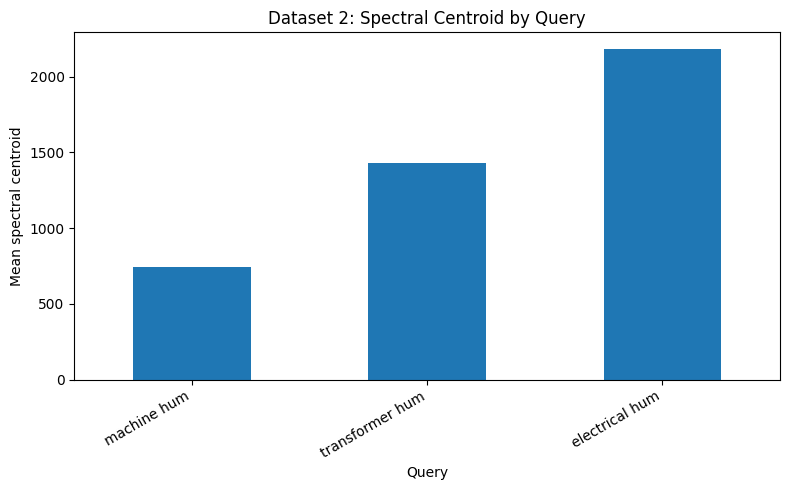

Saved file: ..\04_outputs\dataset2_spectral_centroid_by_query.png


In [6]:
import matplotlib.pyplot as plt

plot_df = (
    df_v5_analysis_subset
    .groupby("query")["spectral_centroid_mean"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plot_df.plot(kind="bar")
plt.ylabel("Mean spectral centroid")
plt.xlabel("Query")
plt.title("Dataset 2: Spectral Centroid by Query")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

outputs_dir = os.path.join(project_root, "04_outputs")
plot_file = os.path.join(outputs_dir, "dataset2_spectral_centroid_by_query.png")
plt.savefig(plot_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_file)

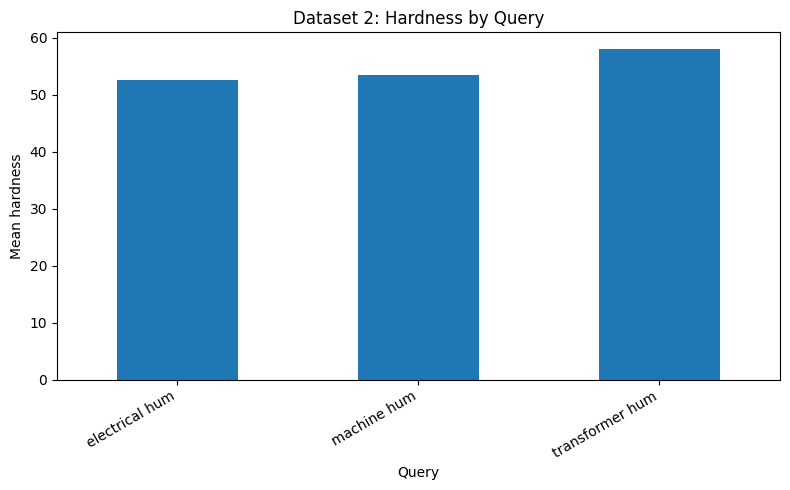

Saved file: ..\04_outputs\dataset2_hardness_by_query.png


In [7]:
plot_df = (
    df_v5_analysis_subset
    .groupby("query")["hardness"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plot_df.plot(kind="bar")
plt.ylabel("Mean hardness")
plt.xlabel("Query")
plt.title("Dataset 2: Hardness by Query")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plot_file = os.path.join(outputs_dir, "dataset2_hardness_by_query.png")
plt.savefig(plot_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_file)

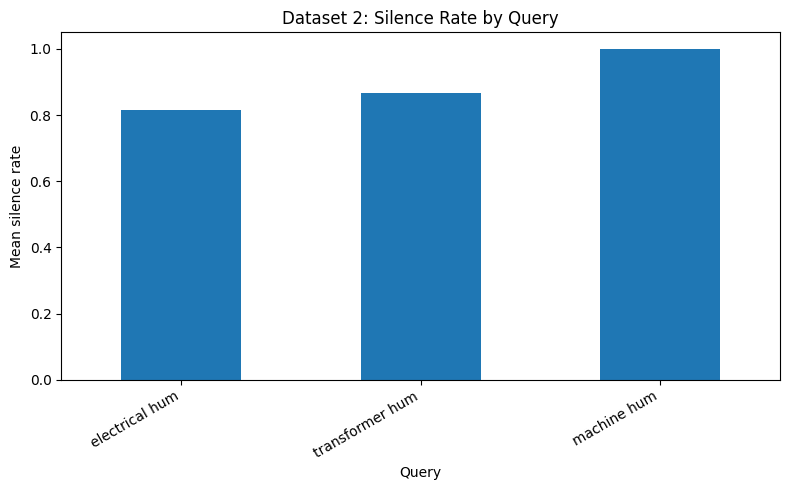

Saved file: ..\04_outputs\dataset2_silence_rate_by_query.png


In [8]:
plot_df = (
    df_v5_analysis_subset
    .groupby("query")["silence_rate_mean"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plot_df.plot(kind="bar")
plt.ylabel("Mean silence rate")
plt.xlabel("Query")
plt.title("Dataset 2: Silence Rate by Query")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plot_file = os.path.join(outputs_dir, "dataset2_silence_rate_by_query.png")
plt.savefig(plot_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_file)

In [9]:
display(df_feature_summary)

,query,bpm,spectral_centroid_mean,spectral_complexity_mean,silence_rate_mean,spectral_energy_mean,hardness,duration_effective
0,electrical hum,105.268,2184.226,6.585,0.816,0.113,52.528,10.655
1,machine hum,148.667,746.135,1.787,1.000,0.001,53.375,9.395
2,transformer hum,99.938,1429.218,5.396,0.866,0.053,58.011,8.059
